# 숙제 3

데이터과학 입문

이성진 (서울대학교 통계학과)  
June 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

## 필요 패키지 로드

## R

``` r
library(tidyverse)
library(NHANES)
library(broom)
library(Lahman)
library(MASS)
```

## Python

``` python
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
from statsmodels.datasets import get_rdataset
import pylahman
from scipy.optimize import curve_fit
from scipy.stats import t
import statsmodels.api as sm
import matplotlib.pyplot as plt
```

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

### 답안

## R

``` r
# 1. 20세 이상 + 현재 흡연 여부 재코딩
nhanes_smoke <- NHANES %>%
  filter(Age >= 20) %>%
  mutate(
    CurrentSmoke = case_when(
      Smoke100 == "No" ~ 0,
      Smoke100 == "Yes" & SmokeNow == "Yes" ~ 1,
      Smoke100 == "Yes" & SmokeNow == "No" ~ 0,
      TRUE ~ NA_real_
    )
  )

# 재코딩 확인
table(nhanes_smoke$CurrentSmoke, useNA = "ifany")
```


       0    1 
    5769 1466 

``` r
# 2. 분석에 사용할 변수 선택
model_data <- nhanes_smoke %>%
  dplyr::select(
    CurrentSmoke,
    Age, Gender, Race1, Education, MaritalStatus,
    Poverty, BMI, HealthGen, PhysActive
  ) %>%
  drop_na()

# 3. 로지스틱 회귀모형
smoke_fit <- glm(
  CurrentSmoke ~ Age + Gender + Race1 + Education + MaritalStatus +
    Poverty + BMI + HealthGen + PhysActive,
  data = model_data,
  family = binomial
)

summary(smoke_fit)
```


    Call:
    glm(formula = CurrentSmoke ~ Age + Gender + Race1 + Education + 
        MaritalStatus + Poverty + BMI + HealthGen + PhysActive, family = binomial, 
        data = model_data)

    Coefficients:
                               Estimate Std. Error z value Pr(>|z|)    
    (Intercept)                1.820567   0.340971   5.339 9.33e-08 ***
    Age                       -0.024468   0.002724  -8.982  < 2e-16 ***
    Gendermale                 0.348450   0.072716   4.792 1.65e-06 ***
    Race1Hispanic             -0.636975   0.185865  -3.427 0.000610 ***
    Race1Mexican              -1.146267   0.178014  -6.439 1.20e-10 ***
    Race1White                 0.195761   0.114358   1.712 0.086929 .  
    Race1Other                 0.117593   0.168563   0.698 0.485412    
    Education9 - 11th Grade    0.194530   0.168346   1.156 0.247871    
    EducationHigh School      -0.366479   0.166704  -2.198 0.027922 *  
    EducationSome College     -0.593495   0.167214  -3.549 0.000386 ***
    EducationCollege Grad     -1.280323   0.186084  -6.880 5.97e-12 ***
    MaritalStatusLivePartner   0.383175   0.147646   2.595 0.009453 ** 
    MaritalStatusMarried      -0.859318   0.114098  -7.531 5.02e-14 ***
    MaritalStatusNeverMarried -0.546721   0.133810  -4.086 4.39e-05 ***
    MaritalStatusSeparated    -0.329735   0.237990  -1.385 0.165901    
    MaritalStatusWidowed      -0.850565   0.196455  -4.330 1.49e-05 ***
    Poverty                   -0.106514   0.025636  -4.155 3.26e-05 ***
    BMI                       -0.051876   0.005820  -8.913  < 2e-16 ***
    HealthGenVgood             0.567785   0.156019   3.639 0.000273 ***
    HealthGenGood              0.970676   0.152420   6.368 1.91e-10 ***
    HealthGenFair              1.360293   0.168796   8.059 7.70e-16 ***
    HealthGenPoor              1.215996   0.256269   4.745 2.09e-06 ***
    PhysActiveYes             -0.550342   0.077403  -7.110 1.16e-12 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 6015.9  on 5999  degrees of freedom
    Residual deviance: 5041.6  on 5977  degrees of freedom
    AIC: 5087.6

    Number of Fisher Scoring iterations: 5

``` r
# 4. Odds Ratio와 95% CI 보기
tidy(smoke_fit, exponentiate = TRUE, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), round, 3))
```

    # A tibble: 23 × 7
       term                  estimate std.error statistic p.value conf.low conf.high
       <chr>                    <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
     1 (Intercept)              6.18      0.341     5.34    0        3.16     12.0  
     2 Age                      0.976     0.003    -8.98    0        0.971     0.981
     3 Gendermale               1.42      0.073     4.79    0        1.23      1.63 
     4 Race1Hispanic            0.529     0.186    -3.43    0.001    0.366     0.758
     5 Race1Mexican             0.318     0.178    -6.44    0        0.223     0.449
     6 Race1White               1.22      0.114     1.71    0.087    0.974     1.52 
     7 Race1Other               1.12      0.169     0.698   0.485    0.807     1.56 
     8 Education9 - 11th Gr…    1.22      0.168     1.16    0.248    0.875     1.69 
     9 EducationHigh School     0.693     0.167    -2.20    0.028    0.501     0.964
    10 EducationSome College    0.552     0.167    -3.55    0        0.399     0.769
    # ℹ 13 more rows

``` r
# 5. 각 predictor의 전체 유의성 검정
drop1(smoke_fit, test = "Chisq")
```

    Single term deletions

    Model:
    CurrentSmoke ~ Age + Gender + Race1 + Education + MaritalStatus + 
        Poverty + BMI + HealthGen + PhysActive
                  Df Deviance    AIC     LRT  Pr(>Chi)    
    <none>             5041.6 5087.6                      
    Age            1   5125.9 5169.9  84.290 < 2.2e-16 ***
    Gender         1   5064.8 5108.8  23.144 1.503e-06 ***
    Race1          4   5143.2 5181.2 101.558 < 2.2e-16 ***
    Education      4   5173.1 5211.1 131.495 < 2.2e-16 ***
    MaritalStatus  5   5180.3 5216.3 138.676 < 2.2e-16 ***
    Poverty        1   5058.9 5102.9  17.311 3.173e-05 ***
    BMI            1   5127.8 5171.8  86.180 < 2.2e-16 ***
    HealthGen      4   5133.0 5171.0  91.370 < 2.2e-16 ***
    PhysActive     1   5092.7 5136.7  51.117 8.701e-13 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

## Python

``` python
NHANES = r.NHANES

# 1. 20세 이상 + CurrentSmoke 재코딩
nhanes_smoke = NHANES.query("Age >= 20").copy()

nhanes_smoke["CurrentSmoke"] = np.select(
    [
        nhanes_smoke["Smoke100"] == "No",
        (nhanes_smoke["Smoke100"] == "Yes") & (nhanes_smoke["SmokeNow"] == "Yes"),
        (nhanes_smoke["Smoke100"] == "Yes") & (nhanes_smoke["SmokeNow"] == "No")
    ],
    [0, 1, 0],
    default=np.nan
)

# 2. 분석에 사용할 변수 선택 + 결측 제거
vars_used = [
    "CurrentSmoke",
    "Age", "Gender", "Race1", "Education", "MaritalStatus",
    "Poverty", "BMI", "HealthGen", "PhysActive"
]

model_data = nhanes_smoke[vars_used].dropna().copy()

# 3. 기준범주 맞추기
model_data["Gender"] = pd.Categorical(
    model_data["Gender"],
    categories=["female", "male"]
)

model_data["Race1"] = pd.Categorical(
    model_data["Race1"],
    categories=["Black", "Hispanic", "Mexican", "White", "Other"]
)

model_data["Education"] = pd.Categorical(
    model_data["Education"],
    categories=["8th Grade", "9 - 11th Grade", "High School",
                "Some College", "College Grad"]
)

model_data["MaritalStatus"] = pd.Categorical(
    model_data["MaritalStatus"],
    categories=["Divorced", "LivePartner", "Married",
                "NeverMarried", "Separated", "Widowed"]
)

model_data["HealthGen"] = pd.Categorical(
    model_data["HealthGen"],
    categories=["Excellent", "Vgood", "Good", "Fair", "Poor"]
)

model_data["PhysActive"] = pd.Categorical(
    model_data["PhysActive"],
    categories=["No", "Yes"]
)

# 4. Logistic regression
formula = """
CurrentSmoke ~ Age + C(Gender) + C(Race1) + C(Education)
+ C(MaritalStatus) + Poverty + BMI + C(HealthGen) + C(PhysActive)
"""

smoke_fit = smf.glm(
    formula=formula,
    data=model_data,
    family=sm.families.Binomial()
).fit()

print(smoke_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           CurrentSmoke   No. Observations:                 6000
    Model:                            GLM   Df Residuals:                     5977
    Model Family:                Binomial   Df Model:                           22
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -2520.8
    Date:                Sat, 13 Jun 2026   Deviance:                       5041.6
    Time:                        07:33:06   Pearson chi2:                 6.06e+03
    No. Iterations:                     6   Pseudo R-squ. (CS):             0.1499
    Covariance Type:            nonrobust                                         
    ====================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
    ----------------------------------------------------------------------------------------------------
    Intercept                            1.8206      0.341      5.339      0.000       1.152       2.489
    C(Gender)[T.male]                    0.3485      0.073      4.792      0.000       0.206       0.491
    C(Race1)[T.Hispanic]                -0.6370      0.186     -3.427      0.001      -1.001      -0.273
    C(Race1)[T.Mexican]                 -1.1463      0.178     -6.439      0.000      -1.495      -0.797
    C(Race1)[T.White]                    0.1958      0.114      1.712      0.087      -0.028       0.420
    C(Race1)[T.Other]                    0.1176      0.169      0.698      0.485      -0.213       0.448
    C(Education)[T.9 - 11th Grade]       0.1945      0.168      1.156      0.248      -0.135       0.524
    C(Education)[T.High School]         -0.3665      0.167     -2.198      0.028      -0.693      -0.040
    C(Education)[T.Some College]        -0.5935      0.167     -3.549      0.000      -0.921      -0.266
    C(Education)[T.College Grad]        -1.2803      0.186     -6.880      0.000      -1.645      -0.916
    C(MaritalStatus)[T.LivePartner]      0.3832      0.148      2.595      0.009       0.094       0.673
    C(MaritalStatus)[T.Married]         -0.8593      0.114     -7.531      0.000      -1.083      -0.636
    C(MaritalStatus)[T.NeverMarried]    -0.5467      0.134     -4.086      0.000      -0.809      -0.284
    C(MaritalStatus)[T.Separated]       -0.3297      0.238     -1.385      0.166      -0.796       0.137
    C(MaritalStatus)[T.Widowed]         -0.8506      0.196     -4.330      0.000      -1.236      -0.466
    C(HealthGen)[T.Vgood]                0.5678      0.156      3.639      0.000       0.262       0.874
    C(HealthGen)[T.Good]                 0.9707      0.152      6.368      0.000       0.672       1.269
    C(HealthGen)[T.Fair]                 1.3603      0.169      8.059      0.000       1.029       1.691
    C(HealthGen)[T.Poor]                 1.2160      0.256      4.745      0.000       0.714       1.718
    C(PhysActive)[T.Yes]                -0.5503      0.077     -7.110      0.000      -0.702      -0.399
    Age                                 -0.0245      0.003     -8.982      0.000      -0.030      -0.019
    Poverty                             -0.1065      0.026     -4.155      0.000      -0.157      -0.056
    BMI                                 -0.0519      0.006     -8.913      0.000      -0.063      -0.040
    ====================================================================================================

현재 흡연 여부를 종속변수로 한 로지스틱 회귀분석 결과, 대부분의 변수들이
현재 흡연과 유의한 관련이 있었다. 전체 변수 단위의 검정인 drop1()
결과에서도 Age, Gender, Race1, Education, MaritalStatus, Poverty, BMI,
HealthGen, PhysActive 모두 유의하였다.

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$  WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}$$

### 답안

## R

``` r
# 0. 데이터 전처리

teams_dat <- Teams %>%
  filter(yearID >= 2010, yearID <= 2025, yearID != 2020) %>%
  transmute(
    yearID,
    lgID,
    teamID,
    name,
    W,
    L,
    G = W + L,
    RS = R,
    RA = RA,
    WPct = W / (W + L)
  ) %>%
  filter(
    !is.na(WPct),
    !is.na(RS),
    !is.na(RA),
    RS > 0,
    RA > 0,
    G > 0
  ) %>%
  mutate(
    log_RS_RA = log(RS / RA),
    log_RS = log(RS),
    log_RA = log(RA)
  )

# 1. Bill James 공식 변형 모형
bj_fit <- nls(
  WPct ~ 1 / (1 + (RA / RS)^k),
  data = teams_dat,
  start = list(k = 2),
  weights = G
)

summary(bj_fit)
```


    Formula: WPct ~ 1/(1 + (RA/RS)^k)

    Parameters:
      Estimate Std. Error t value Pr(>|t|)    
    k  1.75282    0.02935   59.72   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    Residual standard error: 0.3128 on 449 degrees of freedom

    Number of iterations to convergence: 2 
    Achieved convergence tolerance: 9.412e-07

``` r
# 2. k의 점추정치와 신뢰구간
k_est <- coef(bj_fit)["k"]

k_ci <- confint.default(bj_fit)

tibble(
  term = "k",
  estimate = k_est,
  conf.low = k_ci["k", 1],
  conf.high = k_ci["k", 2]
)
```

    # A tibble: 1 × 4
      term  estimate conf.low conf.high
      <chr>    <dbl>    <dbl>     <dbl>
    1 k         1.75     1.70      1.81

## Python

``` python
Teams = pylahman.Teams()
teams_dat = (
    Teams
    .query("2010 <= yearID <= 2025 and yearID != 2020")
    .assign(
        G=lambda d: d["W"] + d["L"],
        RS=lambda d: d["R"],
        WPct=lambda d: d["W"] / (d["W"] + d["L"])
    )
    .loc[:, ["yearID", "lgID", "teamID", "name", "W", "L", "G", "RS", "RA", "WPct"]]
    .dropna()
    .query("RS > 0 and RA > 0 and G > 0")
    .assign(
        log_RS_RA=lambda d: np.log(d["RS"] / d["RA"]),
        log_RS=lambda d: np.log(d["RS"]),
        log_RA=lambda d: np.log(d["RA"])
    )
)

def bill_james_model(x, k):
    RS, RA = x
    return 1 / (1 + (RA / RS) ** k)
  
popt, pcov = curve_fit(
    bill_james_model,
    xdata=(teams_dat["RS"].to_numpy(), teams_dat["RA"].to_numpy()),
    ydata=teams_dat["WPct"].to_numpy(),
    p0=[2],
    sigma=1 / np.sqrt(teams_dat["G"].to_numpy()),
    absolute_sigma=False
)

k_est = popt[0]
k_se = np.sqrt(pcov[0, 0])
df = len(teams_dat) - 1
k_ci = (
    k_est - t.ppf(0.975, df) * k_se,
    k_est + t.ppf(0.975, df) * k_se
)

print("Bill James nls result")
```

    Bill James nls result

``` python
print(f"k estimate: {k_est:.4f}")
```

    k estimate: 1.7611

``` python
print(f"95% CI: ({k_ci[0]:.4f}, {k_ci[1]:.4f})")
```

    95% CI: (1.7020, 1.8202)

1.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

### 답안

## R

``` r
# 절편 없는 로지스틱 회귀모형
glm_k_fit <- glm(
  cbind(W, L) ~ 0 + log_RS_RA,
  data = teams_dat,
  family = binomial
)

summary(glm_k_fit)
```


    Call:
    glm(formula = cbind(W, L) ~ 0 + log_RS_RA, family = binomial, 
        data = teams_dat)

    Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
    log_RS_RA  1.75320    0.04562   38.43   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 450  degrees of freedom
    Residual deviance:  180.26  on 449  degrees of freedom
    AIC: 2665.5

    Number of Fisher Scoring iterations: 3

``` r
# 회귀계수 beta1의 점추정치와 신뢰구간
beta1_est <- coef(glm_k_fit)["log_RS_RA"]
beta1_ci <- confint.default(glm_k_fit)

tibble(
  term = "beta1",
  estimate = beta1_est,
  conf.low = beta1_ci["log_RS_RA", 1],
  conf.high = beta1_ci["log_RS_RA", 2]
)
```

    # A tibble: 1 × 4
      term  estimate conf.low conf.high
      <chr>    <dbl>    <dbl>     <dbl>
    1 beta1     1.75     1.66      1.84

``` r
# 비교
bind_rows(
  tibble(
    model = "Bill James nls",
    term = "k",
    estimate = k_est,
    conf.low = k_ci["k", 1],
    conf.high = k_ci["k", 2]
  ),
  tibble(
    model = "No-intercept logistic glm",
    term = "beta1",
    estimate = beta1_est,
    conf.low = beta1_ci["log_RS_RA", 1],
    conf.high = beta1_ci["log_RS_RA", 2]
  )
)
```

    # A tibble: 2 × 5
      model                     term  estimate conf.low conf.high
      <chr>                     <chr>    <dbl>    <dbl>     <dbl>
    1 Bill James nls            k         1.75     1.70      1.81
    2 No-intercept logistic glm beta1     1.75     1.66      1.84

## Python

``` python
# logit(WPct) = beta1 * log(RS / RA)
num_cols = ["W", "L", "G", "RS", "RA", "WPct", "log_RS_RA", "log_RS", "log_RA"]

teams_dat[num_cols] = teams_dat[num_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

teams_dat = teams_dat.dropna(subset=num_cols).copy()

# 반응변수: R의 cbind(W, L)에 해당
y = teams_dat[["W", "L"]].astype(float)

# 설명변수: 절편 없이 log_RS_RA만 포함
X_k = teams_dat[["log_RS_RA"]].astype(float)

glm_k_fit = sm.GLM(
    y,
    X_k,
    family=sm.families.Binomial()
).fit()

print(glm_k_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:             ['W', 'L']   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      419
    Model Family:                Binomial   Df Model:                            0
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1241.6
    Date:                Sat, 13 Jun 2026   Deviance:                       165.67
    Time:                        07:33:07   Pearson chi2:                     165.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9672
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    log_RS_RA      1.7608      0.047     37.356      0.000       1.668       1.853
    ==============================================================================

``` python
beta1_est = glm_k_fit.params["log_RS_RA"]
beta1_ci = glm_k_fit.conf_int().loc["log_RS_RA"]

print("\nComparison with Problem 1")
```


    Comparison with Problem 1

``` python
print(f"Bill James k: {k_est:.4f}")
```

    Bill James k: 1.7611

``` python
print(f"Logistic beta1: {beta1_est:.4f}")
```

    Logistic beta1: 1.7608

``` python
print(f"beta1 95% CI: ({beta1_ci[0]:.4f}, {beta1_ci[1]:.4f})")
```

    beta1 95% CI: (1.6684, 1.8532)

1번의 nls 모형과 2번의 glm 모형은 수학적으로 매우 비슷한 형태를 가진다.
다만 nls는 승률의 예측오차를 최소화하는 방식이고, glm은 승패를
이항분포로 보고 likelihood를 최대화하는 방식이다. 따라서 추정치가 완전히
같지는 않으나, 비슷한 값이 나온 것을 확인해 (두 추정치 모두 1.75에
가깝다) 두 접근법이 같은 실질적 결론을 준다고 해석할 수 있다.

1.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

### 답안

## R

``` r
# 모형진단
diag_dat <- teams_dat %>%
  mutate(
    eta = predict(glm_k_fit, type = "link"),
    pred_WPct = predict(glm_k_fit, type = "response"),
    dev_resid = residuals(glm_k_fit, type = "deviance")
  )

ggplot(diag_dat, aes(x = eta, y = dev_resid)) +
  geom_point(alpha = 0.7) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    x = "Linear predictor eta",
    y = "Deviance residual",
    title = "Deviance residuals vs linear predictors"
  ) +
  theme_minimal()
```

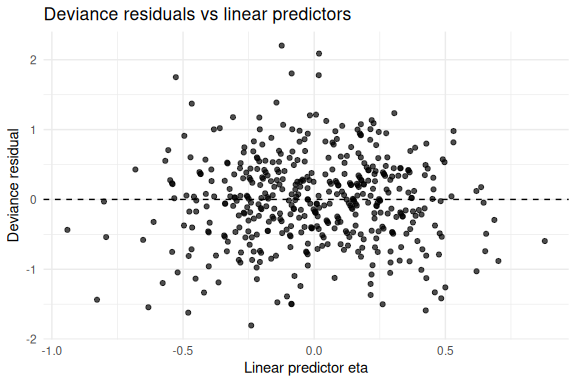

``` r
ggplot(diag_dat, aes(x = pred_WPct, y = WPct)) +
  geom_point(alpha = 0.7) +
  geom_abline(intercept = 0, slope = 1, color = "red") +
  labs(
    x = "Predicted WPct",
    y = "Observed WPct",
    title = "Observed vs predicted winning percentage"
  ) +
  theme_minimal()
```

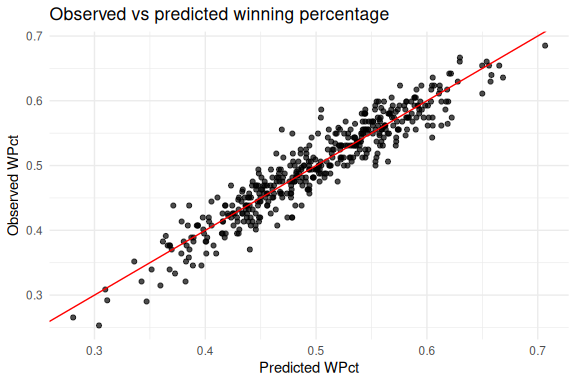

## Python

``` python
# 모형 진단
diag_dat = teams_dat.copy()
diag_dat["eta"] = np.dot(X_k, glm_k_fit.params)
diag_dat["pred_WPct"] = glm_k_fit.predict(X_k)
diag_dat["dev_resid"] = glm_k_fit.resid_deviance

# ii. Deviance residuals vs linear predictors
plt.figure(figsize=(7, 5))
plt.scatter(diag_dat["eta"], diag_dat["dev_resid"], alpha=0.7)
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Linear predictor eta")
plt.ylabel("Deviance residual")
plt.title("Deviance residuals vs linear predictors")
plt.show()
```

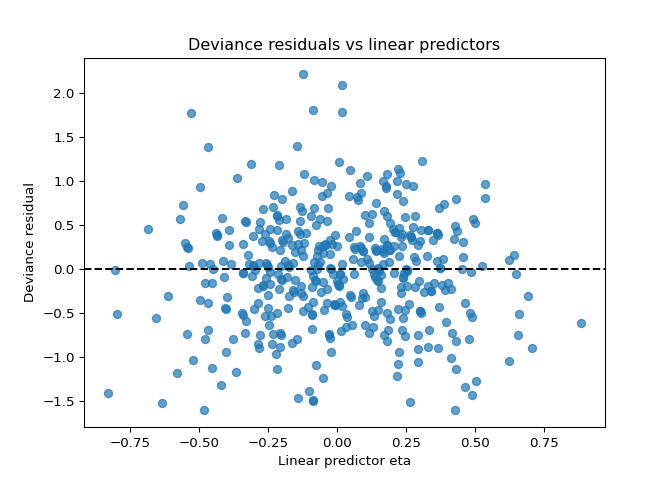

``` python
# iii. Observed WPct vs predicted WPct
plt.figure(figsize=(6, 6))
plt.scatter(diag_dat["pred_WPct"], diag_dat["WPct"], alpha=0.7)
plt.plot([0, 1], [0, 1], color="red")
plt.xlabel("Predicted WPct")
plt.ylabel("Observed WPct")
plt.title("Observed vs predicted winning percentage")
plt.xlim(0.25, 0.75)
```

    (0.25, 0.75)

``` python
plt.ylim(0.25, 0.75)
```

    (0.25, 0.75)

``` python
plt.show()
```

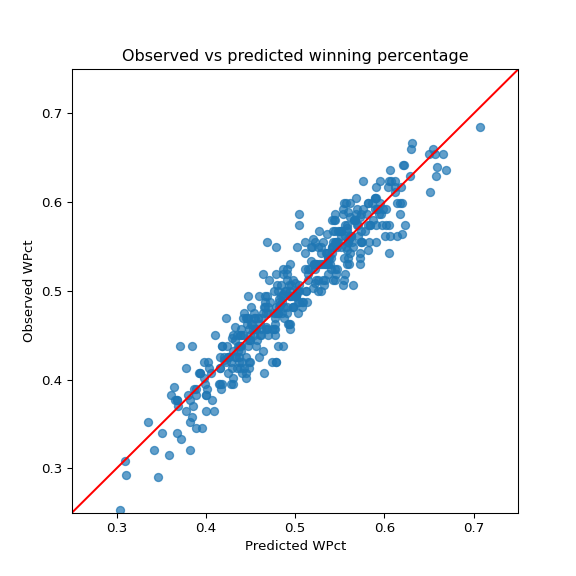

Deviance residuals vs linear predictors 산점도의 경우 산점도점들이 0을
중심으로 특별한 곡선 패턴 없이 흩어져 있으면 모형이 비교적 적절하다고 볼
수 있다.

또한 관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프는 모형이
예측한 승률과 실제 승률을 비교한다. 점들이 y=x 근처에 모여 있으면 예측이
실제 승률과 잘 맞는다는 뜻으로, 대체로 적합이 잘 되었음을 확인할 수
있다.

1.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

## R

``` r
glm_ab_fit <- glm(
  cbind(W, L) ~ 0 + log_RS + log_RA,
  data = teams_dat,
  family = binomial
)

summary(glm_ab_fit)
```


    Call:
    glm(formula = cbind(W, L) ~ 0 + log_RS + log_RA, family = binomial, 
        data = teams_dat)

    Coefficients:
           Estimate Std. Error z value Pr(>|z|)    
    log_RS  1.75315    0.04562   38.43   <2e-16 ***
    log_RA -1.75356    0.04563  -38.43   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 450  degrees of freedom
    Residual deviance:  180.13  on 448  degrees of freedom
    AIC: 2667.4

    Number of Fisher Scoring iterations: 3

``` r
ab_ci <- confint.default(glm_ab_fit)

tibble(
  term = names(coef(glm_ab_fit)),
  estimate = coef(glm_ab_fit),
  conf.low = ab_ci[, 1],
  conf.high = ab_ci[, 2]
)
```

    # A tibble: 2 × 4
      term   estimate conf.low conf.high
      <chr>     <dbl>    <dbl>     <dbl>
    1 log_RS     1.75     1.66      1.84
    2 log_RA    -1.75    -1.84     -1.66

``` r
compare_coef <- tibble(
  quantity = c(
    "nls k",
    "glm beta1",
    "a: coefficient of log(RS)",
    "-b: negative coefficient of log(RA)",
    "a + b"
  ),
  estimate = c(
    k_est,
    beta1_est,
    coef(glm_ab_fit)["log_RS"],
    -coef(glm_ab_fit)["log_RA"],
    coef(glm_ab_fit)["log_RS"] + coef(glm_ab_fit)["log_RA"]
  )
)

compare_coef
```

    # A tibble: 5 × 2
      quantity                             estimate
      <chr>                                   <dbl>
    1 nls k                                1.75    
    2 glm beta1                            1.75    
    3 a: coefficient of log(RS)            1.75    
    4 -b: negative coefficient of log(RA)  1.75    
    5 a + b                               -0.000409

``` r
anova(glm_k_fit, glm_ab_fit, test = "Chisq")
```

    Analysis of Deviance Table

    Model 1: cbind(W, L) ~ 0 + log_RS_RA
    Model 2: cbind(W, L) ~ 0 + log_RS + log_RA
      Resid. Df Resid. Dev Df Deviance Pr(>Chi)
    1       449     180.26                     
    2       448     180.13  1  0.12843   0.7201

``` r
AIC(glm_k_fit, glm_ab_fit)
```

               df      AIC
    glm_k_fit   1 2665.508
    glm_ab_fit  2 2667.379

## Python

``` python
# 절편 없는 로지스틱 회귀

num_cols = ["W", "L", "G", "RS", "RA", "WPct", "log_RS_RA", "log_RS", "log_RA"]

teams_dat[num_cols] = teams_dat[num_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

teams_dat = teams_dat.dropna(subset=num_cols).copy()

y = teams_dat[["W", "L"]].astype("float64")
X_ab = teams_dat[["log_RS", "log_RA"]].astype("float64")

glm_ab_fit = sm.GLM(
    y,
    X_ab,
    family=sm.families.Binomial()
).fit()

print(glm_ab_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:             ['W', 'L']   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      418
    Model Family:                Binomial   Df Model:                            1
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1241.6
    Date:                Sat, 13 Jun 2026   Deviance:                       165.58
    Time:                        07:33:08   Pearson chi2:                     165.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9672
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    log_RS         1.7607      0.047     37.354      0.000       1.668       1.853
    log_RA        -1.7611      0.047    -37.354      0.000      -1.854      -1.669
    ==============================================================================

``` python
a_est = glm_ab_fit.params["log_RS"]
b_est = glm_ab_fit.params["log_RA"]

compare_table = pd.DataFrame({
    "quantity": [
        "Bill James nls k",
        "log(RS/RA) glm beta1",
        "a = coefficient of log(RS)",
        "b = coefficient of log(RA)",
        "-b"
    ],
    "estimate": [
        k_est,
        beta1_est,
        a_est,
        b_est,
        -b_est
    ]
})

print(compare_table)
```

                         quantity  estimate
    0            Bill James nls k  1.761072
    1        log(RS/RA) glm beta1  1.760815
    2  a = coefficient of log(RS)  1.760742
    3  b = coefficient of log(RA) -1.761107
    4                          -b  1.761107

``` python
# 2번 모형과 4번 모형의 적합도 비교
lrt = glm_k_fit.deviance - glm_ab_fit.deviance
df_diff = glm_k_fit.df_resid - glm_ab_fit.df_resid
lrt_p = chi2.sf(lrt, df_diff)

print("\nModel comparison")
```


    Model comparison

``` python
print(f"AIC of log(RS/RA) model: {glm_k_fit.aic:.4f}")
```

    AIC of log(RS/RA) model: 2485.2866

``` python
print(f"AIC of log(RS), log(RA) model: {glm_ab_fit.aic:.4f}")
```

    AIC of log(RS), log(RA) model: 2487.1910

``` python
print(f"LRT statistic: {lrt:.4f}")
```

    LRT statistic: 0.0956

``` python
print(f"df difference: {df_diff:.0f}")
```

    df difference: 1

``` python
print(f"LRT p-value: {lrt_p:.4f}")
```

    LRT p-value: 0.7571

이 모형은 log(RS / RA)를 하나의 변수로 넣는 대신, log(RS)와 log(RA)를
따로 넣은 모형이다.

4번 모형에서 log(RS)의 회귀계수 a는 1.75, log(RA)의 회귀계수 b는 -1.75로
추정되었다. 이는 1번의 Bill James 모형에서 추정된 k = 1.75 및 2번의
log(RS/RA) 로지스틱 회귀모형의 beta1 = 1.75와 거의 동일하다.

Bill James 모형은 로짓 형태로 쓰면 logit(WPct) = k log(RS) - k
log(RA)이므로, log(RS)의 계수는 k, log(RA)의 계수는 -k가 된다. 실제 분석
결과에서도 a = 1.75, b = -1.75로 나타났으므로 4번의 절편 없는 로지스틱
회귀모형은 Bill James 모형과 유사한 모형을 얻었다고 볼 수 있다.

즉, 득점이 증가하면 승률은 증가하고 실점이 증가하면 승률은 감소하며, 두
효과의 크기는 거의 대칭적이다.

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

## R

``` r
# 1. 데이터 준비

vars_22 <- c(
  "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
  "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
  "E", "DP", "FP", "SV"
)

teams22 <- Teams %>%
  filter(yearID >= 2010, yearID <= 2025, yearID != 2020) %>%
  mutate(
    G = W + L,
    WPct = W / (W + L),
    logRS = log(R),
    logRA = log(RA),
    logRSRA = log(R / RA)
  ) %>%
  dplyr::select(
    yearID, lgID, teamID, name,
    W, L, G, WPct, logRSRA, logRS, logRA,
    all_of(vars_22)
  ) %>%
  mutate(
    across(
      c(W, L, G, WPct, logRSRA, logRS, logRA, all_of(vars_22)),
      as.numeric
    )
  ) %>%
  drop_na() %>%
  filter(G > 0)

# 관측단위 중복 확인
teams22 %>%
  count(yearID, teamID, lgID) %>%
  filter(n > 1)
```

    [1] yearID teamID lgID   n     
    <0 rows> (or 0-length row.names)

``` r
# 2. 절편 있는 full logistic model

full_formula <- as.formula(
  paste(
    "cbind(W, L) ~",
    paste(c("logRS", "logRA", vars_22), collapse = " + ")
  )
)

full_fit <- glm(
  full_formula,
  data = teams22,
  family = binomial
)

summary(full_fit)
```


    Call:
    glm(formula = full_formula, family = binomial, data = teams22)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -6.295e+00  2.164e+01  -0.291   0.7712    
    logRS        1.798e+00  2.399e-01   7.494 6.70e-14 ***
    logRA       -8.176e-01  4.583e-01  -1.784   0.0744 .  
    H           -1.988e-04  2.253e-04  -0.882   0.3776    
    X2B         -2.403e-05  4.222e-04  -0.057   0.9546    
    X3B         -5.939e-04  1.037e-03  -0.573   0.5669    
    HR          -2.086e-04  4.590e-04  -0.454   0.6495    
    BB          -2.100e-04  1.939e-04  -1.083   0.2788    
    SO          -8.226e-05  9.049e-05  -0.909   0.3633    
    CS          -1.054e-03  8.776e-04  -1.201   0.2297    
    HBP          1.106e-04  5.563e-04   0.199   0.8424    
    SF          -7.419e-04  1.147e-03  -0.647   0.5177    
    ERA         -3.388e-03  1.137e-01  -0.030   0.9762    
    CG           5.981e-03  3.710e-03   1.612   0.1069    
    SHO          4.140e-03  2.592e-03   1.597   0.1102    
    IPouts       4.424e-04  2.735e-04   1.618   0.1057    
    HA          -3.322e-04  2.455e-04  -1.353   0.1760    
    HRA         -6.512e-04  4.947e-04  -1.316   0.1880    
    BBA         -1.764e-04  2.063e-04  -0.855   0.3925    
    SOA          4.445e-05  1.011e-04   0.440   0.6601    
    E           -3.508e-04  3.567e-03  -0.098   0.9217    
    DP           3.774e-04  5.431e-04   0.695   0.4871    
    FP          -1.389e+00  2.166e+01  -0.064   0.9489    
    SV           1.106e-02  1.404e-03   7.880 3.28e-15 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.541  on 449  degrees of freedom
    Residual deviance:   95.956  on 426  degrees of freedom
    AIC: 2627.2

    Number of Fisher Scoring iterations: 3

``` r
AIC(full_fit)
```

    [1] 2627.2

``` r
# 3. AIC 기준 stepwise variable selection

step_fit <- step(
  full_fit,
  direction = "both",
  trace = 1
)
```

    Start:  AIC=2627.2
    cbind(W, L) ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + 
        CS + HBP + SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + 
        SOA + E + DP + FP + SV

             Df Deviance    AIC
    - ERA     1   95.956 2625.2
    - X2B     1   95.959 2625.2
    - FP      1   95.960 2625.2
    - E       1   95.965 2625.2
    - HBP     1   95.995 2625.2
    - SOA     1   96.149 2625.4
    - HR      1   96.162 2625.4
    - X3B     1   96.283 2625.5
    - SF      1   96.374 2625.6
    - DP      1   96.438 2625.7
    - BBA     1   96.687 2625.9
    - H       1   96.734 2626.0
    - SO      1   96.782 2626.0
    - BB      1   97.129 2626.4
    - CS      1   97.398 2626.6
    - HRA     1   97.689 2626.9
    - HA      1   97.786 2627.0
    <none>        95.956 2627.2
    - SHO     1   98.507 2627.8
    - CG      1   98.556 2627.8
    - IPouts  1   98.573 2627.8
    - logRA   1   99.138 2628.4
    - logRS   1  152.176 2681.4
    - SV      1  158.117 2687.4

    Step:  AIC=2625.2
    cbind(W, L) ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + 
        CS + HBP + SF + CG + SHO + IPouts + HA + HRA + BBA + SOA + 
        E + DP + FP + SV

             Df Deviance    AIC
    - X2B     1   95.960 2623.2
    - FP      1   95.961 2623.2
    - E       1   95.966 2623.2
    - HBP     1   95.996 2623.2
    - SOA     1   96.150 2623.4
    - HR      1   96.167 2623.4
    - X3B     1   96.296 2623.5
    - SF      1   96.375 2623.6
    - DP      1   96.441 2623.7
    - H       1   96.735 2624.0
    - BBA     1   96.767 2624.0
    - SO      1   96.782 2624.0
    - BB      1   97.130 2624.4
    - CS      1   97.404 2624.7
    - HRA     1   97.954 2625.2
    <none>        95.956 2625.2
    - HA      1   98.019 2625.3
    - SHO     1   98.514 2625.8
    - CG      1   98.556 2625.8
    - IPouts  1   99.236 2626.5
    + ERA     1   95.956 2627.2
    - logRA   1  107.751 2635.0
    - logRS   1  152.399 2679.6
    - SV      1  158.914 2686.2

    Step:  AIC=2623.2
    cbind(W, L) ~ logRS + logRA + H + X3B + HR + BB + SO + CS + HBP + 
        SF + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + 
        FP + SV

             Df Deviance    AIC
    - FP      1   95.964 2621.2
    - E       1   95.970 2621.2
    - HBP     1   96.001 2621.2
    - SOA     1   96.152 2621.4
    - HR      1   96.173 2621.4
    - X3B     1   96.296 2621.5
    - SF      1   96.376 2621.6
    - DP      1   96.456 2621.7
    - BBA     1   96.768 2622.0
    - H       1   96.807 2622.1
    - SO      1   96.810 2622.1
    - BB      1   97.132 2622.4
    - CS      1   97.407 2622.7
    - HRA     1   97.955 2623.2
    <none>        95.960 2623.2
    - HA      1   98.049 2623.3
    - SHO     1   98.548 2623.8
    - CG      1   98.559 2623.8
    - IPouts  1   99.243 2624.5
    + X2B     1   95.956 2625.2
    + ERA     1   95.959 2625.2
    - logRA   1  107.754 2633.0
    - logRS   1  158.132 2683.4
    - SV      1  159.052 2684.3

    Step:  AIC=2621.21
    cbind(W, L) ~ logRS + logRA + H + X3B + HR + BB + SO + CS + HBP + 
        SF + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + 
        SV

             Df Deviance    AIC
    - HBP     1   96.006 2619.2
    - E       1   96.011 2619.3
    - SOA     1   96.180 2619.4
    - HR      1   96.183 2619.4
    - X3B     1   96.320 2619.6
    - SF      1   96.376 2619.6
    - DP      1   96.465 2619.7
    - BBA     1   96.772 2620.0
    - SO      1   96.811 2620.1
    - H       1   96.817 2620.1
    - BB      1   97.169 2620.4
    - CS      1   97.416 2620.7
    - HRA     1   97.963 2621.2
    <none>        95.964 2621.2
    - HA      1   98.061 2621.3
    - SHO     1   98.568 2621.8
    - CG      1   98.579 2621.8
    - IPouts  1   99.620 2622.9
    + FP      1   95.960 2623.2
    + X2B     1   95.961 2623.2
    + ERA     1   95.963 2623.2
    - logRA   1  107.761 2631.0
    - logRS   1  158.390 2681.6
    - SV      1  159.103 2682.3

    Step:  AIC=2619.25
    cbind(W, L) ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + 
        CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + SV

             Df Deviance    AIC
    - E       1   96.050 2617.3
    - SOA     1   96.240 2617.5
    - HR      1   96.256 2617.5
    - X3B     1   96.403 2617.7
    - SF      1   96.444 2617.7
    - DP      1   96.513 2617.8
    - BBA     1   96.820 2618.1
    - SO      1   96.852 2618.1
    - H       1   97.010 2618.3
    - BB      1   97.268 2618.5
    - CS      1   97.425 2618.7
    - HRA     1   97.998 2619.2
    <none>        96.006 2619.2
    - HA      1   98.151 2619.4
    - CG      1   98.584 2619.8
    - SHO     1   98.646 2619.9
    - IPouts  1   99.686 2620.9
    + HBP     1   95.964 2621.2
    + X2B     1   96.000 2621.2
    + FP      1   96.001 2621.2
    + ERA     1   96.005 2621.2
    - logRA   1  107.763 2629.0
    - SV      1  159.458 2680.7
    - logRS   1  164.225 2685.5

    Step:  AIC=2617.29
    cbind(W, L) ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + 
        CG + SHO + IPouts + HA + HRA + BBA + SOA + DP + SV

             Df Deviance    AIC
    - SOA     1   96.287 2615.5
    - HR      1   96.306 2615.6
    - X3B     1   96.454 2615.7
    - SF      1   96.472 2615.7
    - DP      1   96.539 2615.8
    - BBA     1   96.865 2616.1
    - SO      1   96.927 2616.2
    - H       1   97.094 2616.3
    - BB      1   97.350 2616.6
    - CS      1   97.531 2616.8
    - HRA     1   98.004 2617.2
    <none>        96.050 2617.3
    - HA      1   98.182 2617.4
    - CG      1   98.595 2617.8
    - SHO     1   98.747 2618.0
    - IPouts  1   99.707 2618.9
    + E       1   96.006 2619.2
    + HBP     1   96.011 2619.3
    + FP      1   96.012 2619.3
    + X2B     1   96.041 2619.3
    + ERA     1   96.044 2619.3
    - logRA   1  108.308 2627.6
    - SV      1  159.462 2678.7
    - logRS   1  165.106 2684.3

    Step:  AIC=2615.53
    cbind(W, L) ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + 
        CG + SHO + IPouts + HA + HRA + BBA + DP + SV

             Df Deviance    AIC
    - HR      1   96.516 2613.8
    - DP      1   96.621 2613.9
    - X3B     1   96.700 2613.9
    - SF      1   96.746 2614.0
    - SO      1   97.012 2614.3
    - BBA     1   97.068 2614.3
    - H       1   97.227 2614.5
    - BB      1   97.616 2614.9
    - HRA     1   98.061 2615.3
    - CS      1   98.104 2615.3
    <none>        96.287 2615.5
    - CG      1   98.678 2615.9
    - SHO     1   99.092 2616.3
    - HA      1   99.224 2616.5
    + SOA     1   96.050 2617.3
    + HBP     1   96.230 2617.5
    + E       1   96.240 2617.5
    + FP      1   96.252 2617.5
    + ERA     1   96.281 2617.5
    + X2B     1   96.281 2617.5
    - IPouts  1  100.334 2617.6
    - logRA   1  108.508 2625.8
    - SV      1  160.319 2677.6
    - logRS   1  165.544 2682.8

    Step:  AIC=2613.76
    cbind(W, L) ~ logRS + logRA + H + X3B + BB + SO + CS + SF + CG + 
        SHO + IPouts + HA + HRA + BBA + DP + SV

             Df Deviance    AIC
    - X3B     1   96.781 2612.0
    - DP      1   96.839 2612.1
    - SF      1   96.876 2612.1
    - H       1   97.285 2612.5
    - BBA     1   97.334 2612.6
    - SO      1   97.538 2612.8
    - BB      1   97.693 2612.9
    - CS      1   98.225 2613.5
    <none>        96.516 2613.8
    - HRA     1   98.601 2613.8
    - CG      1   98.853 2614.1
    - SHO     1   99.368 2614.6
    - HA      1   99.531 2614.8
    + HR      1   96.287 2615.5
    + SOA     1   96.306 2615.6
    - IPouts  1  100.414 2615.7
    + HBP     1   96.427 2615.7
    + E       1   96.463 2615.7
    + FP      1   96.478 2615.7
    + X2B     1   96.512 2615.8
    + ERA     1   96.513 2615.8
    - logRA   1  108.627 2623.9
    - SV      1  160.682 2675.9
    - logRS   1  215.370 2730.6

    Step:  AIC=2612.03
    cbind(W, L) ~ logRS + logRA + H + BB + SO + CS + SF + CG + SHO + 
        IPouts + HA + HRA + BBA + DP + SV

             Df Deviance    AIC
    - DP      1   97.119 2610.4
    - SF      1   97.235 2610.5
    - BBA     1   97.637 2610.9
    - H       1   97.805 2611.1
    - BB      1   97.959 2611.2
    - SO      1   98.053 2611.3
    - HRA     1   98.781 2612.0
    <none>        96.781 2612.0
    - CS      1   98.904 2612.2
    - CG      1   99.050 2612.3
    - SHO     1   99.588 2612.8
    - HA      1  100.077 2613.3
    + X3B     1   96.516 2613.8
    + SOA     1   96.555 2613.8
    + HBP     1   96.660 2613.9
    + HR      1   96.700 2613.9
    + E       1   96.723 2614.0
    + FP      1   96.744 2614.0
    + X2B     1   96.777 2614.0
    + ERA     1   96.781 2614.0
    - IPouts  1  100.888 2614.1
    - logRA   1  108.737 2622.0
    - SV      1  161.221 2674.5
    - logRS   1  217.373 2730.6

    Step:  AIC=2610.36
    cbind(W, L) ~ logRS + logRA + H + BB + SO + CS + SF + CG + SHO + 
        IPouts + HA + HRA + BBA + SV

             Df Deviance    AIC
    - SF      1   97.579 2608.8
    - BBA     1   97.780 2609.0
    - H       1   98.123 2609.4
    - SO      1   98.269 2609.5
    - BB      1   98.433 2609.7
    <none>        97.119 2610.4
    - HRA     1   99.144 2610.4
    - CS      1   99.187 2610.4
    - CG      1   99.706 2610.9
    - SHO     1   99.898 2611.1
    - HA      1  100.102 2611.3
    + DP      1   96.781 2612.0
    + X3B     1   96.839 2612.1
    + HBP     1   96.999 2612.2
    + SOA     1   97.043 2612.3
    + HR      1   97.047 2612.3
    + E       1   97.081 2612.3
    + FP      1   97.088 2612.3
    - IPouts  1  101.089 2612.3
    + ERA     1   97.118 2612.4
    + X2B     1   97.119 2612.4
    - logRA   1  110.462 2621.7
    - SV      1  161.631 2672.9
    - logRS   1  219.194 2730.4

    Step:  AIC=2608.82
    cbind(W, L) ~ logRS + logRA + H + BB + SO + CS + CG + SHO + IPouts + 
        HA + HRA + BBA + SV

             Df Deviance    AIC
    - BBA     1   98.130 2607.4
    - SO      1   98.449 2607.7
    - H       1   98.565 2607.8
    - BB      1   99.032 2608.3
    - HRA     1   99.335 2608.6
    <none>        97.579 2608.8
    - CS      1   99.774 2609.0
    - CG      1  100.315 2609.6
    - HA      1  100.322 2609.6
    - SHO     1  100.325 2609.6
    + SF      1   97.119 2610.4
    + X3B     1   97.202 2610.4
    + DP      1   97.235 2610.5
    - IPouts  1  101.396 2610.6
    + HBP     1   97.417 2610.7
    + SOA     1   97.475 2610.7
    + E       1   97.557 2610.8
    + FP      1   97.559 2610.8
    + HR      1   97.565 2610.8
    + ERA     1   97.576 2610.8
    + X2B     1   97.578 2610.8
    - logRA   1  111.864 2621.1
    - SV      1  162.810 2672.1
    - logRS   1  220.710 2729.9

    Step:  AIC=2607.37
    cbind(W, L) ~ logRS + logRA + H + BB + SO + CS + CG + SHO + IPouts + 
        HA + HRA + SV

             Df Deviance    AIC
    - SO      1   98.976 2606.2
    - H       1   99.290 2606.5
    - HRA     1   99.513 2606.8
    - BB      1   99.646 2606.9
    <none>        98.130 2607.4
    - HA      1  100.322 2607.6
    - CS      1  100.605 2607.8
    - SHO     1  101.004 2608.2
    - CG      1  101.178 2608.4
    + BBA     1   97.579 2608.8
    - IPouts  1  101.708 2608.9
    + X3B     1   97.736 2609.0
    + SF      1   97.780 2609.0
    + HBP     1   97.960 2609.2
    + DP      1   97.973 2609.2
    + SOA     1   98.015 2609.3
    + ERA     1   98.079 2609.3
    + E       1   98.102 2609.3
    + HR      1   98.105 2609.3
    + FP      1   98.108 2609.3
    + X2B     1   98.129 2609.4
    - logRA   1  122.381 2629.6
    - SV      1  163.942 2671.2
    - logRS   1  224.530 2731.8

    Step:  AIC=2606.22
    cbind(W, L) ~ logRS + logRA + H + BB + CS + CG + SHO + IPouts + 
        HA + HRA + SV

             Df Deviance    AIC
    - H       1   99.480 2604.7
    - HRA     1  100.415 2605.7
    - BB      1  100.521 2605.8
    <none>        98.976 2606.2
    - HA      1  100.980 2606.2
    - CS      1  101.204 2606.4
    - SHO     1  101.775 2607.0
    - IPouts  1  101.996 2607.2
    + SO      1   98.130 2607.4
    + X3B     1   98.391 2607.6
    + BBA     1   98.449 2607.7
    + HBP     1   98.798 2608.0
    + HR      1   98.830 2608.1
    + SF      1   98.855 2608.1
    + DP      1   98.886 2608.1
    + E       1   98.903 2608.2
    + FP      1   98.913 2608.2
    + ERA     1   98.943 2608.2
    + SOA     1   98.959 2608.2
    + X2B     1   98.976 2608.2
    - CG      1  103.134 2608.4
    - logRA   1  125.916 2631.2
    - SV      1  164.538 2669.8
    - logRS   1  228.080 2733.3

    Step:  AIC=2604.72
    cbind(W, L) ~ logRS + logRA + BB + CS + CG + SHO + IPouts + HA + 
        HRA + SV

             Df Deviance    AIC
    - BB      1   100.53 2603.8
    - HRA     1   100.64 2603.9
    <none>         99.48 2604.7
    - CS      1   101.78 2605.0
    - IPouts  1   102.09 2605.3
    - SHO     1   102.29 2605.5
    - HA      1   102.32 2605.6
    + X3B     1    98.73 2606.0
    + BBA     1    98.82 2606.1
    + H       1    98.98 2606.2
    + HBP     1    99.13 2606.4
    - CG      1   103.18 2606.4
    + SO      1    99.29 2606.5
    + SF      1    99.30 2606.5
    + DP      1    99.38 2606.6
    + E       1    99.39 2606.6
    + FP      1    99.41 2606.7
    + X2B     1    99.42 2606.7
    + ERA     1    99.43 2606.7
    + SOA     1    99.46 2606.7
    + HR      1    99.48 2606.7
    - logRA   1   126.14 2629.4
    - SV      1   165.54 2668.8
    - logRS   1   411.04 2914.3

    Step:  AIC=2603.78
    cbind(W, L) ~ logRS + logRA + CS + CG + SHO + IPouts + HA + HRA + 
        SV

             Df Deviance    AIC
    - HRA     1   101.75 2603.0
    <none>        100.53 2603.8
    - CS      1   102.70 2603.9
    - IPouts  1   102.73 2604.0
    - HA      1   102.91 2604.2
    - SHO     1   103.17 2604.4
    + BB      1    99.48 2604.7
    + X3B     1    99.91 2605.2
    + BBA     1    99.93 2605.2
    + SO      1   100.02 2605.3
    - CG      1   104.09 2605.3
    + HBP     1   100.25 2605.5
    + SF      1   100.33 2605.6
    + DP      1   100.37 2605.6
    + E       1   100.42 2605.7
    + FP      1   100.44 2605.7
    + SOA     1   100.51 2605.8
    + H       1   100.52 2605.8
    + X2B     1   100.52 2605.8
    + HR      1   100.52 2605.8
    + ERA     1   100.52 2605.8
    - logRA   1   127.17 2628.4
    - SV      1   168.40 2669.7
    - logRS   1   498.13 2999.4

    Step:  AIC=2603
    cbind(W, L) ~ logRS + logRA + CS + CG + SHO + IPouts + HA + SV

             Df Deviance    AIC
    - HA      1   103.18 2602.4
    - CS      1   103.62 2602.9
    <none>        101.75 2603.0
    - IPouts  1   103.86 2603.1
    - SHO     1   104.50 2603.8
    + HRA     1   100.53 2603.8
    + BB      1   100.64 2603.9
    + SO      1   101.03 2604.3
    + X3B     1   101.33 2604.6
    - CG      1   105.43 2604.7
    + DP      1   101.52 2604.8
    + ERA     1   101.54 2604.8
    + HBP     1   101.56 2604.8
    + BBA     1   101.57 2604.8
    + HR      1   101.58 2604.8
    + SF      1   101.70 2604.9
    + H       1   101.74 2605.0
    + SOA     1   101.74 2605.0
    + FP      1   101.75 2605.0
    + E       1   101.75 2605.0
    + X2B     1   101.75 2605.0
    - logRA   1   156.73 2656.0
    - SV      1   168.85 2668.1
    - logRS   1   515.75 3015.0

    Step:  AIC=2602.42
    cbind(W, L) ~ logRS + logRA + CS + CG + SHO + IPouts + SV

             Df Deviance    AIC
    - IPouts  1   104.38 2601.6
    <none>        103.18 2602.4
    - CS      1   105.36 2602.6
    - CG      1   105.69 2602.9
    + HA      1   101.75 2603.0
    + X3B     1   102.36 2603.6
    - SHO     1   106.42 2603.7
    + BB      1   102.51 2603.8
    + HBP     1   102.63 2603.9
    + ERA     1   102.77 2604.0
    + SOA     1   102.81 2604.1
    + HRA     1   102.91 2604.2
    + SO      1   103.00 2604.2
    + H       1   103.02 2604.3
    + SF      1   103.09 2604.3
    + X2B     1   103.12 2604.4
    + E       1   103.13 2604.4
    + FP      1   103.16 2604.4
    + HR      1   103.17 2604.4
    + DP      1   103.17 2604.4
    + BBA     1   103.18 2604.4
    - SV      1   168.88 2666.1
    - logRA   1   246.40 2743.7
    - logRS   1   559.35 3056.6

    Step:  AIC=2601.63
    cbind(W, L) ~ logRS + logRA + CS + CG + SHO + SV

             Df Deviance    AIC
    - CS      1   106.12 2601.4
    <none>        104.38 2601.6
    + IPouts  1   103.18 2602.4
    + ERA     1   103.39 2602.6
    - CG      1   107.43 2602.7
    - SHO     1   107.52 2602.8
    + X3B     1   103.70 2602.9
    + HA      1   103.86 2603.1
    + BB      1   103.86 2603.1
    + HRA     1   103.96 2603.2
    + HBP     1   104.02 2603.3
    + SOA     1   104.05 2603.3
    + SO      1   104.19 2603.4
    + SF      1   104.32 2603.6
    + HR      1   104.37 2603.6
    + FP      1   104.37 2603.6
    + E       1   104.37 2603.6
    + H       1   104.38 2603.6
    + DP      1   104.38 2603.6
    + X2B     1   104.38 2603.6
    + BBA     1   104.38 2603.6
    - SV      1   176.23 2671.5
    - logRA   1   262.76 2758.0
    - logRS   1   579.02 3074.3

    Step:  AIC=2601.36
    cbind(W, L) ~ logRS + logRA + CG + SHO + SV

             Df Deviance    AIC
    <none>        106.12 2601.4
    + CS      1   104.38 2601.6
    - CG      1   108.42 2601.7
    + X3B     1   104.83 2602.1
    + ERA     1   105.24 2602.5
    + SOA     1   105.28 2602.5
    + HA      1   105.30 2602.5
    + IPouts  1   105.36 2602.6
    - SHO     1   109.52 2602.8
    + BB      1   105.69 2602.9
    + HBP     1   105.75 2603.0
    + HRA     1   105.92 2603.2
    + SF      1   105.97 2603.2
    + E       1   106.04 2603.3
    + H       1   106.05 2603.3
    + FP      1   106.06 2603.3
    + SO      1   106.06 2603.3
    + HR      1   106.08 2603.3
    + BBA     1   106.09 2603.3
    + DP      1   106.11 2603.4
    + X2B     1   106.12 2603.4
    - SV      1   176.50 2669.8
    - logRA   1   266.78 2760.0
    - logRS   1   616.29 3109.5

``` r
summary(step_fit)
```


    Call:
    glm(formula = cbind(W, L) ~ logRS + logRA + CG + SHO + SV, family = binomial, 
        data = teams22)

    Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -2.694019   0.842064  -3.199  0.00138 ** 
    logRS        1.615284   0.071880  22.472  < 2e-16 ***
    logRA       -1.284160   0.101524 -12.649  < 2e-16 ***
    CG           0.004573   0.003014   1.517  0.12926    
    SHO          0.004669   0.002531   1.845  0.06502 .  
    SV           0.011104   0.001324   8.384  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 449  degrees of freedom
    Residual deviance:  106.12  on 444  degrees of freedom
    AIC: 2601.4

    Number of Fisher Scoring iterations: 3

``` r
AIC(full_fit, step_fit)
```

             df      AIC
    full_fit 24 2627.200
    step_fit  6 2601.364

``` r
# 선택된 변수 확인
names(coef(step_fit))
```

    [1] "(Intercept)" "logRS"       "logRA"       "CG"          "SHO"        
    [6] "SV"         

``` r
# 4. 선택 후 남은 변수들을 계속 남길지 판단

drop1_result <- drop1(step_fit, test = "Chisq")
drop1_result
```

    Single term deletions

    Model:
    cbind(W, L) ~ logRS + logRA + CG + SHO + SV
           Df Deviance    AIC    LRT Pr(>Chi)    
    <none>      106.12 2601.4                    
    logRS   1   616.29 3109.5 510.17  < 2e-16 ***
    logRA   1   266.78 2760.0 160.66  < 2e-16 ***
    CG      1   108.42 2601.7   2.30  0.12919    
    SHO     1   109.52 2602.8   3.40  0.06502 .  
    SV      1   176.50 2669.8  70.38  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
# AIC 기준으로 정렬해서 보기
drop1_result %>%
  as.data.frame() %>%
  rownames_to_column("term") %>%
  arrange(AIC)
```

        term Df Deviance      AIC        LRT      Pr(>Chi)
    1 <none> NA 106.1193 2601.364         NA            NA
    2     CG  1 108.4216 2601.666   2.302232  1.291882e-01
    3    SHO  1 109.5239 2602.768   3.404572  6.501599e-02
    4     SV  1 176.5023 2669.747  70.382998  4.883904e-17
    5  logRA  1 266.7832 2760.028 160.663890  8.102110e-37
    6  logRS  1 616.2883 3109.533 510.168964 5.827105e-113

``` r
# 기본적으로 final_fit은 stepwise 결과로 둔다.

final_fit <- step_fit

# 5. 문제 2-1의 모형과 비교

problem1_fit <- glm(
  cbind(W, L) ~ 0 + logRSRA,
  data = teams22,
  family = binomial
)

compare_models <- tibble(
  model = c(
    "Problem 2-1: no-intercept log(RS/RA)",
    "Problem 2-2: full model",
    "Problem 2-2: stepwise/final model"
  ),
  AIC = c(
    AIC(problem1_fit),
    AIC(full_fit),
    AIC(final_fit)
  ),
  deviance = c(
    deviance(problem1_fit),
    deviance(full_fit),
    deviance(final_fit)
  ),
  df_residual = c(
    df.residual(problem1_fit),
    df.residual(full_fit),
    df.residual(final_fit)
  )
)

compare_models
```

    # A tibble: 3 × 4
      model                                  AIC deviance df_residual
      <chr>                                <dbl>    <dbl>       <int>
    1 Problem 2-1: no-intercept log(RS/RA) 2666.    180.          449
    2 Problem 2-2: full model              2627.     96.0         426
    3 Problem 2-2: stepwise/final model    2601.    106.          444

## Python

``` python
# 1. 데이터 준비

Teams = pylahman.Teams()
Teams = Teams.rename(columns={"2B": "X2B", "3B": "X3B"})
vars_22 = [
    "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
    "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
    "E", "DP", "FP", "SV"
]

needed = ["yearID", "W", "L", "R", "RA"] + vars_22

Teams[needed] = Teams[needed].apply(
    pd.to_numeric,
    errors="coerce"
)

teams22 = Teams.loc[
    (Teams["yearID"] >= 2010)
    & (Teams["yearID"] <= 2025)
    & (Teams["yearID"] != 2020)
].copy()

teams22["G"] = teams22["W"] + teams22["L"]
teams22["WPct"] = teams22["W"] / teams22["G"]
teams22["logRS"] = np.log(teams22["R"])
teams22["logRA"] = np.log(teams22["RA"])
teams22["logRSRA"] = np.log(teams22["R"] / teams22["RA"])

keep_cols = [
    "yearID", "lgID", "teamID", "name",
    "W", "L", "G", "WPct", "logRSRA", "logRS", "logRA"
] + vars_22

teams22 = (
    teams22[keep_cols]
    .dropna()
    .query("G > 0")
    .copy()
)

# 2. 절편 있는 full logistic model

model_terms = ["logRS", "logRA"] + vars_22

y = teams22[["W", "L"]].astype("float64")

def fit_glm(terms):
    X = teams22[terms].astype("float64")
    X = sm.add_constant(X, has_constant="add")
    return sm.GLM(y, X, family=sm.families.Binomial()).fit()

full_fit = fit_glm(model_terms)

print(full_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:             ['W', 'L']   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      396
    Model Family:                Binomial   Df Model:                           23
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1203.6
    Date:                Sat, 13 Jun 2026   Deviance:                       89.521
    Time:                        07:33:09   Pearson chi2:                     89.5
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9726
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -5.5146     22.820     -0.242      0.809     -50.240      39.211
    logRS          1.7820      0.248      7.180      0.000       1.296       2.269
    logRA         -0.7694      0.474     -1.624      0.104      -1.698       0.159
    H             -0.0002      0.000     -0.793      0.428      -0.001       0.000
    X2B         8.479e-06      0.000      0.019      0.985      -0.001       0.001
    X3B           -0.0005      0.001     -0.416      0.678      -0.003       0.002
    HR            -0.0002      0.000     -0.389      0.697      -0.001       0.001
    BB            -0.0002      0.000     -0.990      0.322      -0.001       0.000
    SO         -7.811e-05   9.29e-05     -0.841      0.400      -0.000       0.000
    CS            -0.0011      0.001     -1.229      0.219      -0.003       0.001
    HBP         7.042e-05      0.001      0.122      0.903      -0.001       0.001
    SF            -0.0007      0.001     -0.622      0.534      -0.003       0.002
    ERA           -0.0270      0.118     -0.227      0.820      -0.259       0.205
    CG             0.0057      0.004      1.485      0.138      -0.002       0.013
    SHO            0.0038      0.003      1.427      0.154      -0.001       0.009
    IPouts         0.0004      0.000      1.411      0.158      -0.000       0.001
    HA            -0.0003      0.000     -1.312      0.190      -0.001       0.000
    HRA           -0.0006      0.001     -1.256      0.209      -0.002       0.000
    BBA           -0.0002      0.000     -0.766      0.444      -0.001       0.000
    SOA         3.815e-05      0.000      0.367      0.713      -0.000       0.000
    E             -0.0005      0.004     -0.146      0.884      -0.008       0.007
    DP             0.0005      0.001      0.869      0.385      -0.001       0.002
    FP            -2.1151     22.793     -0.093      0.926     -46.788      42.558
    SV             0.0108      0.001      7.466      0.000       0.008       0.014
    ==============================================================================

``` python
print("Full model AIC:", full_fit.aic)
```

    Full model AIC: 2455.1341311534666

``` python
# 3. AIC 기준 stepwise variable selection

def stepwise_aic(all_terms, start_terms=None, verbose=True, tol=1e-7):
    included = list(all_terms if start_terms is None else start_terms)

    best_fit = fit_glm(included)
    best_aic = best_fit.aic

    while True:
        candidates = []

        # drop step
        for term in included:
            new_terms = [t for t in included if t != term]
            fit = fit_glm(new_terms)
            candidates.append(("drop", term, new_terms, fit.aic, fit))

        # add step
        excluded = [t for t in all_terms if t not in included]
        for term in excluded:
            new_terms = included + [term]
            fit = fit_glm(new_terms)
            candidates.append(("add", term, new_terms, fit.aic, fit))

        if not candidates:
            break

        action, term, new_terms, new_aic, new_fit = min(
            candidates,
            key=lambda x: x[3]
        )

        if new_aic < best_aic - tol:
            included = new_terms
            best_aic = new_aic
            best_fit = new_fit

            if verbose:
                print(f"{action:4s} {term:8s} AIC = {best_aic:.4f}")
        else:
            break

    return included, best_fit

selected_terms, step_fit = stepwise_aic(
    model_terms,
    start_terms=model_terms,
    verbose=True
)
```

    drop X2B      AIC = 2453.1345
    drop FP       AIC = 2451.1429
    drop HBP      AIC = 2449.1583
    drop ERA      AIC = 2447.2081
    drop E        AIC = 2445.2571
    drop SOA      AIC = 2443.4407
    drop HR       AIC = 2441.6381
    drop X3B      AIC = 2439.7760
    drop SF       AIC = 2438.1424
    drop DP       AIC = 2436.7735
    drop BBA      AIC = 2435.2209
    drop SO       AIC = 2433.8756
    drop H        AIC = 2432.2624
    drop BB       AIC = 2431.1780
    drop HRA      AIC = 2430.6410
    drop HA       AIC = 2429.7189
    drop IPouts   AIC = 2428.7325
    drop CS       AIC = 2428.5409

``` python
print("\nSelected terms:")
```


    Selected terms:

``` python
print(selected_terms)
```

    ['logRS', 'logRA', 'CG', 'SHO', 'SV']

``` python
print(step_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:             ['W', 'L']   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      414
    Model Family:                Binomial   Df Model:                            5
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1208.3
    Date:                Sat, 13 Jun 2026   Deviance:                       98.928
    Time:                        07:33:12   Pearson chi2:                     98.9
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9720
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -2.4801      0.865     -2.866      0.004      -4.176      -0.784
    logRS          1.6169      0.074     21.973      0.000       1.473       1.761
    logRA         -1.3159      0.105    -12.501      0.000      -1.522      -1.110
    CG             0.0044      0.003      1.435      0.151      -0.002       0.011
    SHO            0.0043      0.003      1.653      0.098      -0.001       0.009
    SV             0.0108      0.001      7.936      0.000       0.008       0.013
    ==============================================================================

``` python
print("Stepwise model AIC:", step_fit.aic)
```

    Stepwise model AIC: 2428.54089768661

``` python
# 4. 선택 후 남은 변수들을 계속 남길지 판단

def drop1_table(terms):
    full = fit_glm(terms)
    rows = [{
        "term": "<none>",
        "Df": np.nan,
        "Deviance": full.deviance,
        "AIC": full.aic,
        "LRT": np.nan,
        "Pr(>Chi)": np.nan
    }]

    for term in terms:
        reduced_terms = [t for t in terms if t != term]
        reduced = fit_glm(reduced_terms)

        lrt = reduced.deviance - full.deviance
        df = reduced.df_resid - full.df_resid
        p_value = chi2.sf(lrt, df)

        rows.append({
            "term": term,
            "Df": df,
            "Deviance": reduced.deviance,
            "AIC": reduced.aic,
            "LRT": lrt,
            "Pr(>Chi)": p_value
        })

    return pd.DataFrame(rows).sort_values("AIC")

drop1_result = drop1_table(selected_terms)
print(drop1_result)
```

         term   Df    Deviance          AIC         LRT       Pr(>Chi)
    0  <none>  NaN   98.927724  2428.540898         NaN            NaN
    3      CG  1.0  100.988422  2428.601596    2.060698   1.511409e-01
    4     SHO  1.0  101.658677  2429.271851    2.730953   9.842053e-02
    5      SV  1.0  161.959597  2489.572771   63.031873   2.033886e-15
    2   logRA  1.0  255.876922  2583.490096  156.949198   5.251107e-36
    1   logRS  1.0  586.872603  2914.485777  487.944880  3.990109e-108

``` python
# 기본적으로 final model은 stepwise 결과로 둔다.
final_terms = selected_terms
final_fit = step_fit

# 5. 문제 2-1의 모형과 비교

# 문제 2-1 모형: 절편 없는 log(RS/RA) 모형
X_problem1 = teams22[["logRSRA"]].astype("float64")

problem1_fit = sm.GLM(
    y,
    X_problem1,
    family=sm.families.Binomial()
).fit()

compare_models = pd.DataFrame({
    "model": [
        "Problem 2-1: no-intercept log(RS/RA)",
        "Problem 2-2: full model",
        "Problem 2-2: stepwise/final model"
    ],
    "AIC": [
        problem1_fit.aic,
        full_fit.aic,
        final_fit.aic
    ],
    "deviance": [
        problem1_fit.deviance,
        full_fit.deviance,
        final_fit.deviance
    ],
    "df_residual": [
        problem1_fit.df_resid,
        full_fit.df_resid,
        final_fit.df_resid
    ]
})

print(compare_models)
```

                                      model          AIC    deviance  df_residual
    0  Problem 2-1: no-intercept log(RS/RA)  2485.286598  165.673424          419
    1               Problem 2-2: full model  2455.134131   89.520957          396
    2     Problem 2-2: stepwise/final model  2428.540898   98.927724          414

full model은 logRS, logRA와 팀의 타격, 투구, 수비 지표를 모두 포함한
절편 있는 로지스틱 회귀모형이다.

stepwise selection을 통해 AIC를 기준으로 변수를 제거하거나 추가하면서 더
낮은 AIC를 갖는 모형을 도출했다. stepwise 이후 drop1 결과를 보면, 선택된
각 변수를 하나씩 제거했을 때 AIC와 deviance가 어떻게 변하는지 확인할 수
있는데 <none>의 AIC가 가장 작으므로 추가적인 변수 제거 없이 변수를
유지하는 것이 적절하다.

최종 모형의 AIC가 문제 2-1의 단순한 log(RS/RA) 모형보다 낮기 때문에,
추가적인 타격, 투구, 수비 변수들이 승률 설명에 도움을 준다고 볼 수 있다.
다만 문제 2-1 모형은 매우 단순하고 해석이 쉬운 반면, 문제 2-2 모형은
예측력은 높을 수 있지만 더 복잡하다.

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

2.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

## R

``` r
# 데이터 준비
vars_23 <- c(
  "logRS", "logRA",
  "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
  "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
  "E", "DP", "FP", "SV"
)

teams23 <- Teams %>%
  filter(yearID >= 2010, yearID <= 2025, yearID != 2020) %>%
  mutate(
    G = W + L,
    WPct = W / G,
    logRS = log(R),
    logRA = log(RA),
    logRSRA = log(R / RA)
  ) %>%
  dplyr::select(
    yearID, lgID, teamID, name,
    W, L, G, WPct, logRSRA,
    all_of(vars_23)
  ) %>%
  mutate(across(c(W, L, G, WPct, logRSRA, all_of(vars_23)), as.numeric)) %>%
  drop_na() %>%
  filter(G > 0)

# 문제 2-2와 비교하기 위한 binomial stepwise model
binom_full <- glm(
  cbind(W, L) ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + SF +
    ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + FP + SV,
  data = teams23,
  family = binomial
)

binom_step <- step(binom_full, direction = "both", trace = 0)

# 1. Poisson regression: W를 반응변수로 사용
pois_full <- glm(
  W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + SF +
    ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + FP + SV +
    offset(log(G)),
  data = teams23,
  family = poisson
)

pois_step <- step(pois_full, direction = "both", trace = 1)
```

    Start:  AIC=2903.7
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + 
        SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + 
        DP + FP + SV + offset(log(G))

             Df Deviance    AIC
    - E       1   55.845 2901.7
    - FP      1   55.846 2901.7
    - HBP     1   55.860 2901.7
    - X2B     1   55.906 2901.8
    - SOA     1   55.963 2901.8
    - X3B     1   56.030 2901.9
    - logRA   1   56.067 2901.9
    - SF      1   56.086 2901.9
    - HR      1   56.210 2902.1
    - BBA     1   56.224 2902.1
    - DP      1   56.264 2902.1
    - CS      1   56.317 2902.2
    - SO      1   56.361 2902.2
    - H       1   56.372 2902.2
    - ERA     1   56.403 2902.3
    - BB      1   56.566 2902.4
    - HA      1   56.634 2902.5
    - HRA     1   56.784 2902.6
    - IPouts  1   56.795 2902.7
    - SHO     1   57.177 2903.0
    - CG      1   57.371 2903.2
    <none>        55.842 2903.7
    - logRS   1   87.223 2933.1
    - SV      1   90.947 2936.8

    Step:  AIC=2901.7
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + 
        SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + DP + 
        FP + SV + offset(log(G))

             Df Deviance    AIC
    - HBP     1   55.863 2899.7
    - X2B     1   55.910 2899.8
    - SOA     1   55.981 2899.8
    - X3B     1   56.044 2899.9
    - logRA   1   56.073 2899.9
    - SF      1   56.086 2899.9
    - FP      1   56.217 2900.1
    - HR      1   56.222 2900.1
    - BBA     1   56.227 2900.1
    - DP      1   56.275 2900.1
    - CS      1   56.323 2900.2
    - SO      1   56.362 2900.2
    - H       1   56.379 2900.2
    - ERA     1   56.403 2900.3
    - BB      1   56.590 2900.4
    - HA      1   56.640 2900.5
    - HRA     1   56.788 2900.7
    - IPouts  1   56.853 2900.7
    - SHO     1   57.186 2901.1
    - CG      1   57.382 2901.2
    <none>        55.845 2901.7
    + E       1   55.842 2903.7
    - logRS   1   87.581 2931.4
    - SV      1   90.986 2934.8

    Step:  AIC=2899.72
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + SF + 
        ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + DP + FP + 
        SV + offset(log(G))

             Df Deviance    AIC
    - X2B     1   55.934 2897.8
    - SOA     1   56.009 2897.9
    - X3B     1   56.083 2897.9
    - logRA   1   56.092 2897.9
    - SF      1   56.118 2898.0
    - FP      1   56.227 2898.1
    - BBA     1   56.252 2898.1
    - HR      1   56.276 2898.1
    - DP      1   56.297 2898.2
    - CS      1   56.329 2898.2
    - SO      1   56.377 2898.2
    - ERA     1   56.414 2898.3
    - H       1   56.471 2898.3
    - BB      1   56.641 2898.5
    - HA      1   56.680 2898.5
    - HRA     1   56.810 2898.7
    - IPouts  1   56.893 2898.8
    - SHO     1   57.222 2899.1
    - CG      1   57.383 2899.2
    <none>        55.863 2899.7
    + HBP     1   55.845 2901.7
    + E       1   55.860 2901.7
    - logRS   1   90.806 2932.7
    - SV      1   91.156 2933.0

    Step:  AIC=2897.79
    W ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + ERA + 
        CG + SHO + IPouts + HA + HRA + BBA + SOA + DP + FP + SV + 
        offset(log(G))

             Df Deviance    AIC
    - SOA     1   56.072 2895.9
    - X3B     1   56.132 2896.0
    - logRA   1   56.146 2896.0
    - SF      1   56.183 2896.0
    - HR      1   56.284 2896.1
    - BBA     1   56.306 2896.2
    - FP      1   56.339 2896.2
    - CS      1   56.369 2896.2
    - DP      1   56.392 2896.2
    - SO      1   56.499 2896.4
    - ERA     1   56.522 2896.4
    - H       1   56.707 2896.6
    - BB      1   56.712 2896.6
    - HA      1   56.774 2896.6
    - HRA     1   56.854 2896.7
    - IPouts  1   56.914 2896.8
    - SHO     1   57.355 2897.2
    - CG      1   57.416 2897.3
    <none>        55.934 2897.8
    + X2B     1   55.863 2899.7
    + HBP     1   55.910 2899.8
    + E       1   55.930 2899.8
    - SV      1   91.385 2931.2
    - logRS   1   93.114 2933.0

    Step:  AIC=2895.93
    W ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + ERA + 
        CG + SHO + IPouts + HA + HRA + BBA + DP + FP + SV + offset(log(G))

             Df Deviance    AIC
    - X3B     1   56.279 2894.1
    - logRA   1   56.287 2894.2
    - SF      1   56.342 2894.2
    - HR      1   56.398 2894.3
    - DP      1   56.425 2894.3
    - BBA     1   56.430 2894.3
    - FP      1   56.465 2894.3
    - SO      1   56.546 2894.4
    - CS      1   56.630 2894.5
    - ERA     1   56.653 2894.5
    - H       1   56.773 2894.6
    - BB      1   56.861 2894.7
    - HRA     1   56.898 2894.8
    - IPouts  1   57.172 2895.0
    - HA      1   57.240 2895.1
    - CG      1   57.462 2895.3
    - SHO     1   57.550 2895.4
    <none>        56.072 2895.9
    + SOA     1   55.934 2897.8
    + X2B     1   56.009 2897.9
    + HBP     1   56.037 2897.9
    + E       1   56.050 2897.9
    - SV      1   91.782 2929.6
    - logRS   1   93.317 2931.2

    Step:  AIC=2894.14
    W ~ logRS + logRA + H + HR + BB + SO + CS + SF + ERA + CG + SHO + 
        IPouts + HA + HRA + BBA + DP + FP + SV + offset(log(G))

             Df Deviance    AIC
    - logRA   1   56.445 2892.3
    - HR      1   56.477 2892.3
    - SF      1   56.585 2892.4
    - DP      1   56.638 2892.5
    - BBA     1   56.643 2892.5
    - FP      1   56.715 2892.6
    - ERA     1   56.958 2892.8
    - SO      1   56.968 2892.8
    - CS      1   56.976 2892.8
    - BB      1   57.040 2892.9
    - H       1   57.073 2892.9
    - HRA     1   57.078 2892.9
    - IPouts  1   57.361 2893.2
    - HA      1   57.538 2893.4
    - CG      1   57.601 2893.5
    - SHO     1   57.747 2893.6
    <none>        56.279 2894.1
    + X3B     1   56.072 2895.9
    + SOA     1   56.132 2896.0
    + HBP     1   56.219 2896.1
    + E       1   56.233 2896.1
    + X2B     1   56.238 2896.1
    - SV      1   91.828 2927.7
    - logRS   1   93.616 2929.5

    Step:  AIC=2892.3
    W ~ logRS + H + HR + BB + SO + CS + SF + ERA + CG + SHO + IPouts + 
        HA + HRA + BBA + DP + FP + SV + offset(log(G))

             Df Deviance    AIC
    - HR      1   56.637 2890.5
    - SF      1   56.787 2890.7
    - BBA     1   56.825 2890.7
    - DP      1   56.841 2890.7
    - CS      1   57.113 2891.0
    - SO      1   57.209 2891.1
    - H       1   57.218 2891.1
    - BB      1   57.220 2891.1
    - HRA     1   57.241 2891.1
    - IPouts  1   57.388 2891.2
    - FP      1   57.396 2891.3
    - HA      1   57.812 2891.7
    - CG      1   57.826 2891.7
    - SHO     1   58.076 2891.9
    <none>        56.445 2892.3
    + logRA   1   56.279 2894.1
    + X3B     1   56.287 2894.2
    + SOA     1   56.295 2894.2
    + HBP     1   56.388 2894.2
    + E       1   56.393 2894.2
    + X2B     1   56.413 2894.3
    - ERA     1   61.241 2895.1
    - SV      1   92.167 2926.0
    - logRS   1   93.659 2927.5

    Step:  AIC=2890.5
    W ~ logRS + H + BB + SO + CS + SF + ERA + CG + SHO + IPouts + 
        HA + HRA + BBA + DP + FP + SV + offset(log(G))

             Df Deviance    AIC
    - SF      1   56.889 2888.8
    - DP      1   57.021 2888.9
    - BBA     1   57.026 2888.9
    - CS      1   57.204 2889.1
    - H       1   57.250 2889.1
    - BB      1   57.305 2889.2
    - IPouts  1   57.504 2889.4
    - SO      1   57.573 2889.4
    - FP      1   57.602 2889.5
    - HRA     1   57.607 2889.5
    - HA      1   57.998 2889.9
    - CG      1   58.002 2889.9
    - SHO     1   58.302 2890.2
    <none>        56.637 2890.5
    + HR      1   56.445 2892.3
    + logRA   1   56.477 2892.3
    + SOA     1   56.510 2892.4
    + HBP     1   56.559 2892.4
    + E       1   56.579 2892.4
    + X3B     1   56.583 2892.4
    + X2B     1   56.633 2892.5
    - ERA     1   61.413 2893.3
    - SV      1   92.353 2924.2
    - logRS   1  117.522 2949.4

    Step:  AIC=2888.75
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HA + 
        HRA + BBA + DP + FP + SV + offset(log(G))

             Df Deviance    AIC
    - BBA     1   57.222 2887.1
    - DP      1   57.282 2887.1
    - H       1   57.494 2887.3
    - CS      1   57.504 2887.4
    - SO      1   57.643 2887.5
    - BB      1   57.650 2887.5
    - IPouts  1   57.697 2887.6
    - HRA     1   57.719 2887.6
    - FP      1   57.839 2887.7
    - HA      1   58.145 2888.0
    - CG      1   58.352 2888.2
    - SHO     1   58.560 2888.4
    <none>        56.889 2888.8
    + SF      1   56.637 2890.5
    + logRA   1   56.698 2890.6
    + SOA     1   56.736 2890.6
    + HR      1   56.787 2890.7
    + HBP     1   56.787 2890.7
    + X3B     1   56.803 2890.7
    + E       1   56.850 2890.7
    + X2B     1   56.885 2890.7
    - ERA     1   62.027 2891.9
    - SV      1   93.036 2922.9
    - logRS   1  118.122 2948.0

    Step:  AIC=2887.08
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HA + 
        HRA + DP + FP + SV + offset(log(G))

             Df Deviance    AIC
    - DP      1   57.478 2885.3
    - HRA     1   57.807 2885.7
    - IPouts  1   57.835 2885.7
    - H       1   57.907 2885.8
    - CS      1   57.916 2885.8
    - SO      1   57.932 2885.8
    - BB      1   58.081 2885.9
    - HA      1   58.145 2886.0
    - FP      1   58.430 2886.3
    - CG      1   58.907 2886.8
    - SHO     1   59.014 2886.9
    <none>        57.222 2887.1
    + BBA     1   56.889 2888.8
    + logRA   1   57.018 2888.9
    + SF      1   57.026 2888.9
    + SOA     1   57.086 2888.9
    + HR      1   57.104 2889.0
    + HBP     1   57.111 2889.0
    + X3B     1   57.140 2889.0
    + E       1   57.178 2889.0
    + X2B     1   57.221 2889.1
    - ERA     1   67.871 2895.7
    - SV      1   93.253 2921.1
    - logRS   1  120.454 2948.3

    Step:  AIC=2885.34
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HA + 
        HRA + FP + SV + offset(log(G))

             Df Deviance    AIC
    - IPouts  1   58.051 2883.9
    - SO      1   58.121 2884.0
    - HRA     1   58.121 2884.0
    - CS      1   58.126 2884.0
    - H       1   58.127 2884.0
    - HA      1   58.186 2884.1
    - BB      1   58.422 2884.3
    - FP      1   58.679 2884.5
    - SHO     1   59.252 2885.1
    - CG      1   59.338 2885.2
    <none>        57.478 2885.3
    + DP      1   57.222 2887.1
    + logRA   1   57.243 2887.1
    + SF      1   57.266 2887.1
    + BBA     1   57.282 2887.1
    + HBP     1   57.368 2887.2
    + HR      1   57.371 2887.2
    + X3B     1   57.392 2887.2
    + SOA     1   57.435 2887.3
    + X2B     1   57.472 2887.3
    + E       1   57.476 2887.3
    - ERA     1   68.494 2894.3
    - SV      1   93.447 2919.3
    - logRS   1  121.085 2946.9

    Step:  AIC=2883.91
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + HA + HRA + FP + 
        SV + offset(log(G))

             Df Deviance    AIC
    - HA      1   58.406 2882.3
    - H       1   58.418 2882.3
    - SO      1   58.481 2882.3
    - HRA     1   58.512 2882.4
    - CS      1   58.538 2882.4
    - BB      1   58.749 2882.6
    - FP      1   59.460 2883.3
    - SHO     1   59.788 2883.7
    - CG      1   59.803 2883.7
    <none>        58.051 2883.9
    + IPouts  1   57.478 2885.3
    + DP      1   57.835 2885.7
    + SF      1   57.871 2885.7
    + HBP     1   57.915 2885.8
    + SOA     1   57.945 2885.8
    + X3B     1   57.947 2885.8
    + logRA   1   57.977 2885.8
    + BBA     1   57.982 2885.8
    + HR      1   57.987 2885.8
    + E       1   58.027 2885.9
    + X2B     1   58.050 2885.9
    - ERA     1   75.592 2899.4
    - SV      1   94.857 2918.7
    - logRS   1  121.359 2945.2

    Step:  AIC=2882.27
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + HRA + FP + SV + 
        offset(log(G))

             Df Deviance    AIC
    - HRA     1   58.666 2880.5
    - SO      1   58.852 2880.7
    - CS      1   58.933 2880.8
    - H       1   59.135 2881.0
    - BB      1   59.237 2881.1
    - CG      1   59.902 2881.8
    - FP      1   60.014 2881.9
    - SHO     1   60.397 2882.3
    <none>        58.406 2882.3
    + HA      1   58.051 2883.9
    + SOA     1   58.104 2884.0
    + IPouts  1   58.186 2884.1
    + HBP     1   58.221 2884.1
    + SF      1   58.257 2884.1
    + logRA   1   58.263 2884.1
    + X3B     1   58.278 2884.1
    + HR      1   58.328 2884.2
    + DP      1   58.349 2884.2
    + E       1   58.402 2884.3
    + X2B     1   58.403 2884.3
    + BBA     1   58.405 2884.3
    - SV      1   95.221 2917.1
    - ERA     1  100.444 2922.3
    - logRS   1  130.318 2952.2

    Step:  AIC=2880.53
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + FP + SV + offset(log(G))

             Df Deviance    AIC
    - CS      1   59.136 2879.0
    - SO      1   59.168 2879.0
    - H       1   59.229 2879.1
    - BB      1   59.465 2879.3
    - FP      1   60.159 2880.0
    - CG      1   60.210 2880.1
    <none>        58.666 2880.5
    - SHO     1   60.675 2880.5
    + HRA     1   58.406 2882.3
    + IPouts  1   58.465 2882.3
    + HBP     1   58.510 2882.4
    + HA      1   58.512 2882.4
    + HR      1   58.517 2882.4
    + logRA   1   58.540 2882.4
    + DP      1   58.555 2882.4
    + SOA     1   58.557 2882.4
    + SF      1   58.566 2882.4
    + X3B     1   58.590 2882.4
    + BBA     1   58.656 2882.5
    + E       1   58.663 2882.5
    + X2B     1   58.666 2882.5
    - SV      1   95.285 2915.1
    - ERA     1  131.125 2951.0
    - logRS   1  137.140 2957.0

    Step:  AIC=2879
    W ~ logRS + H + BB + SO + ERA + CG + SHO + FP + SV + offset(log(G))

             Df Deviance    AIC
    - SO      1   59.559 2877.4
    - H       1   59.769 2877.6
    - BB      1   59.971 2877.8
    - CG      1   60.560 2878.4
    - FP      1   60.823 2878.7
    <none>        59.136 2879.0
    - SHO     1   61.243 2879.1
    + CS      1   58.666 2880.5
    + SOA     1   58.913 2880.8
    + HRA     1   58.933 2880.8
    + HA      1   58.942 2880.8
    + X3B     1   58.953 2880.8
    + logRA   1   59.004 2880.9
    + SF      1   59.006 2880.9
    + HBP     1   59.008 2880.9
    + IPouts  1   59.022 2880.9
    + DP      1   59.059 2880.9
    + HR      1   59.069 2880.9
    + E       1   59.132 2881.0
    + X2B     1   59.135 2881.0
    + BBA     1   59.135 2881.0
    - SV      1   95.333 2913.2
    - ERA     1  132.143 2950.0
    - logRS   1  141.795 2959.7

    Step:  AIC=2877.42
    W ~ logRS + H + BB + ERA + CG + SHO + FP + SV + offset(log(G))

             Df Deviance    AIC
    - H       1   59.836 2875.7
    - BB      1   60.480 2876.3
    - FP      1   61.493 2877.3
    <none>        59.559 2877.4
    - SHO     1   61.635 2877.5
    - CG      1   61.715 2877.6
    + SO      1   59.136 2879.0
    + CS      1   59.168 2879.0
    + HRA     1   59.306 2879.2
    + X3B     1   59.315 2879.2
    + logRA   1   59.364 2879.2
    + HA      1   59.373 2879.2
    + HR      1   59.374 2879.2
    + HBP     1   59.432 2879.3
    + SOA     1   59.469 2879.3
    + DP      1   59.501 2879.4
    + IPouts  1   59.517 2879.4
    + SF      1   59.528 2879.4
    + E       1   59.552 2879.4
    + BBA     1   59.558 2879.4
    + X2B     1   59.559 2879.4
    - SV      1   95.562 2911.4
    - ERA     1  136.841 2952.7
    - logRS   1  146.030 2961.9

    Step:  AIC=2875.7
    W ~ logRS + BB + ERA + CG + SHO + FP + SV + offset(log(G))

             Df Deviance    AIC
    - BB      1   60.485 2874.3
    - CG      1   61.723 2875.6
    <none>        59.836 2875.7
    - FP      1   61.930 2875.8
    - SHO     1   62.024 2875.9
    + CS      1   59.360 2877.2
    + HA      1   59.442 2877.3
    + X3B     1   59.455 2877.3
    + H       1   59.559 2877.4
    + HBP     1   59.568 2877.4
    + logRA   1   59.603 2877.5
    + SOA     1   59.650 2877.5
    + HRA     1   59.751 2877.6
    + SF      1   59.765 2877.6
    + E       1   59.768 2877.6
    + SO      1   59.769 2877.6
    + X2B     1   59.779 2877.6
    + DP      1   59.819 2877.7
    + HR      1   59.825 2877.7
    + BBA     1   59.836 2877.7
    + IPouts  1   59.836 2877.7
    - SV      1   95.585 2909.4
    - ERA     1  136.938 2950.8
    - logRS   1  230.529 3044.4

    Step:  AIC=2874.34
    W ~ logRS + ERA + CG + SHO + FP + SV + offset(log(G))

             Df Deviance    AIC
    <none>        60.485 2874.3
    - CG      1   62.493 2874.3
    - SHO     1   62.532 2874.4
    - FP      1   62.578 2874.4
    + BB      1   59.836 2875.7
    + CS      1   60.061 2875.9
    + logRA   1   60.174 2876.0
    + X3B     1   60.196 2876.1
    + SO      1   60.216 2876.1
    + HA      1   60.217 2876.1
    + HBP     1   60.285 2876.1
    + HRA     1   60.317 2876.2
    + SOA     1   60.375 2876.2
    + SF      1   60.415 2876.3
    + E       1   60.417 2876.3
    + DP      1   60.423 2876.3
    + HR      1   60.442 2876.3
    + X2B     1   60.475 2876.3
    + H       1   60.480 2876.3
    + IPouts  1   60.483 2876.3
    + BBA     1   60.485 2876.3
    - SV      1   98.092 2909.9
    - ERA     1  138.419 2950.3
    - logRS   1  304.984 3116.8

``` r
summary(pois_step)
```


    Call:
    glm(formula = W ~ logRS + ERA + CG + SHO + FP + SV + offset(log(G)), 
        family = poisson, data = teams23)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -8.7647510  2.1702072  -4.039 5.38e-05 ***
    logRS        0.7908948  0.0505703  15.640  < 2e-16 ***
    ERA         -0.1408953  0.0159637  -8.826  < 2e-16 ***
    CG           0.0029466  0.0020762   1.419    0.156    
    SHO          0.0024906  0.0017406   1.431    0.152    
    FP           3.2278606  2.2319213   1.446    0.148    
    SV           0.0056998  0.0009284   6.139 8.30e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 864.116  on 449  degrees of freedom
    Residual deviance:  60.485  on 443  degrees of freedom
    AIC: 2874.3

    Number of Fisher Scoring iterations: 3

``` r
drop1(pois_step, test = "Chisq")
```

    Single term deletions

    Model:
    W ~ logRS + ERA + CG + SHO + FP + SV + offset(log(G))
           Df Deviance    AIC     LRT  Pr(>Chi)    
    <none>      60.485 2874.3                      
    logRS   1  304.984 3116.8 244.499 < 2.2e-16 ***
    ERA     1  138.419 2950.3  77.934 < 2.2e-16 ***
    CG      1   62.493 2874.3   2.007    0.1565    
    SHO     1   62.532 2874.4   2.047    0.1525    
    FP      1   62.578 2874.4   2.092    0.1481    
    SV      1   98.092 2909.9  37.607 8.654e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
# Poisson 과산포 확인
pois_dispersion <- sum(residuals(pois_step, type = "pearson")^2) / df.residual(pois_step)
pois_dispersion
```

    [1] 0.1359442

``` r
# 문제 2-2 binomial model과 예측 성능 비교
teams23 <- teams23 %>%
  mutate(
    pred_binom_WPct = predict(binom_step, type = "response"),
    pred_pois_W = predict(pois_step, type = "response"),
    pred_pois_WPct = pred_pois_W / G
  )

compare_pred <- tibble(
  model = c("Problem 2-2 binomial", "Problem 2-3 Poisson"),
  AIC = c(AIC(binom_step), AIC(pois_step)),
  RMSE_WPct = c(
    sqrt(mean((teams23$WPct - teams23$pred_binom_WPct)^2)),
    sqrt(mean((teams23$WPct - teams23$pred_pois_WPct)^2))
  ),
  cor_WPct = c(
    cor(teams23$WPct, teams23$pred_binom_WPct),
    cor(teams23$WPct, teams23$pred_pois_WPct)
  )
)

compare_pred
```

    # A tibble: 2 × 4
      model                  AIC RMSE_WPct cor_WPct
      <chr>                <dbl>     <dbl>    <dbl>
    1 Problem 2-2 binomial 2601.    0.0188    0.969
    2 Problem 2-3 Poisson  2874.    0.0199    0.965

## Python

``` python
Teams = pylahman.Teams()
Teams = Teams.rename(columns={"2B": "X2B", "3B": "X3B"})

vars_23 = [
    "logRS", "logRA",
    "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
    "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
    "E", "DP", "FP", "SV"
]

raw_vars = [
    "yearID", "lgID", "teamID", "name",
    "W", "L", "R", "RA",
    "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
    "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
    "E", "DP", "FP", "SV"
]

missing = [c for c in raw_vars if c not in Teams.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

num_cols = [c for c in raw_vars if c not in ["lgID", "teamID", "name"]]
Teams[num_cols] = Teams[num_cols].apply(pd.to_numeric, errors="coerce")

teams23 = Teams.loc[
    (Teams["yearID"] >= 2010)
    & (Teams["yearID"] <= 2025)
    & (Teams["yearID"] != 2020)
].copy()

teams23["G"] = teams23["W"] + teams23["L"]
teams23["WPct"] = teams23["W"] / teams23["G"]
teams23["logRS"] = np.log(teams23["R"])
teams23["logRA"] = np.log(teams23["RA"])
teams23["logRSRA"] = np.log(teams23["R"] / teams23["RA"])

keep_cols = [
    "yearID", "lgID", "teamID", "name",
    "W", "L", "G", "WPct", "logRSRA"
] + vars_23

teams23 = (
    teams23[keep_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .query("G > 0")
    .copy()
)

y_binom = teams23[["W", "L"]].astype("float64")
y_count = teams23["W"].astype("float64")
offset_g = np.log(teams23["G"].astype("float64"))

def fit_binom(terms):
    X = teams23[terms].astype("float64")
    X = sm.add_constant(X, has_constant="add")
    return sm.GLM(y_binom, X, family=sm.families.Binomial()).fit()

def fit_poisson(terms):
    X = teams23[terms].astype("float64")
    X = sm.add_constant(X, has_constant="add")
    return sm.GLM(
        y_count,
        X,
        family=sm.families.Poisson(),
        offset=offset_g
    ).fit()

def stepwise_aic(all_terms, fit_func, start_terms=None, verbose=True, tol=1e-7):
    included = list(all_terms if start_terms is None else start_terms)

    best_fit = fit_func(included)
    best_aic = best_fit.aic

    while True:
        candidates = []

        for term in included:
            new_terms = [t for t in included if t != term]
            fit = fit_func(new_terms)
            candidates.append(("drop", term, new_terms, fit.aic, fit))

        excluded = [t for t in all_terms if t not in included]

        for term in excluded:
            new_terms = included + [term]
            fit = fit_func(new_terms)
            candidates.append(("add", term, new_terms, fit.aic, fit))

        if not candidates:
            break

        action, term, new_terms, new_aic, new_fit = min(
            candidates,
            key=lambda x: x[3]
        )

        if new_aic < best_aic - tol:
            included = new_terms
            best_aic = new_aic
            best_fit = new_fit
            if verbose:
                print(f"{action:4s} {term:8s} AIC = {best_aic:.4f}")
        else:
            break

    return included, best_fit

# 문제 2-2와 비교하기 위한 binomial stepwise model
binom_terms, binom_step = stepwise_aic(vars_23, fit_binom, verbose=False)

# 1. Poisson regression
pois_terms, pois_step = stepwise_aic(vars_23, fit_poisson, verbose=True)
```

    drop FP       AIC = 2710.8455
    drop HBP      AIC = 2708.8536
    drop X2B      AIC = 2706.8942
    drop X3B      AIC = 2704.9827
    drop SOA      AIC = 2703.0895
    drop logRA    AIC = 2701.2609
    drop HR       AIC = 2699.4454
    drop SF       AIC = 2697.6565
    drop BBA      AIC = 2695.9392
    drop IPouts   AIC = 2694.3971
    drop H        AIC = 2692.6957
    drop SO       AIC = 2690.8578
    drop DP       AIC = 2689.2760
    drop HA       AIC = 2687.6512
    drop HRA      AIC = 2685.9676
    drop CS       AIC = 2684.3709
    drop BB       AIC = 2683.0278
    drop SHO      AIC = 2682.5754

``` python
print("\nPoisson selected terms:")
```


    Poisson selected terms:

``` python
print(pois_terms)
```

    ['logRS', 'ERA', 'CG', 'E', 'SV']

``` python
print(pois_step.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                      W   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      414
    Model Family:                 Poisson   Df Model:                            5
    Link Function:                    Log   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1335.3
    Date:                Sat, 13 Jun 2026   Deviance:                       57.390
    Time:                        07:33:20   Pearson chi2:                     57.1
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.8339
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -5.4630      0.357    -15.287      0.000      -6.163      -4.763
    logRS          0.7945      0.052     15.295      0.000       0.693       0.896
    ERA           -0.1560      0.014    -11.224      0.000      -0.183      -0.129
    CG             0.0033      0.002      1.579      0.114      -0.001       0.007
    E             -0.0006      0.000     -1.591      0.112      -0.001       0.000
    SV             0.0055      0.001      5.821      0.000       0.004       0.007
    ==============================================================================

``` python
pois_dispersion = np.sum(pois_step.resid_pearson ** 2) / pois_step.df_resid
print("Poisson dispersion ratio:", round(pois_dispersion, 4))
```

    Poisson dispersion ratio: 0.1379

``` python
teams23["pred_binom_WPct"] = binom_step.predict(
    sm.add_constant(teams23[binom_terms].astype("float64"), has_constant="add")
)

teams23["pred_pois_W"] = pois_step.predict(
    sm.add_constant(teams23[pois_terms].astype("float64"), has_constant="add"),
    offset=offset_g
)

teams23["pred_pois_WPct"] = teams23["pred_pois_W"] / teams23["G"]

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

compare_pred = pd.DataFrame({
    "model": ["Problem 2-2 binomial", "Problem 2-3 Poisson"],
    "AIC": [binom_step.aic, pois_step.aic],
    "RMSE_WPct": [
        rmse(teams23["WPct"], teams23["pred_binom_WPct"]),
        rmse(teams23["WPct"], teams23["pred_pois_WPct"])
    ],
    "cor_WPct": [
        np.corrcoef(teams23["WPct"], teams23["pred_binom_WPct"])[0, 1],
        np.corrcoef(teams23["WPct"], teams23["pred_pois_WPct"])[0, 1]
    ]
})

print(compare_pred)
```

                      model          AIC  RMSE_WPct  cor_WPct
    0  Problem 2-2 binomial  2428.540898   0.018830  0.969057
    1   Problem 2-3 Poisson  2682.575408   0.020131  0.964580

문제 2-3에서는 승리 횟수 W를 반응변수로 두고 포아송 회귀모형을
적합하였다. 경기 수 차이를 보정하기 위해 offset(log(G))를 포함하였다. 그
결과 문제 2-3의 Poisson 모형은 AIC = 2874.345, 예측 승률의 RMSE =
0.0199, 관측 승률과 예측 승률의 상관계수 = 0.9651로 나타났다.

반면 문제 2-2의 binomial 로지스틱 모형은 AIC = 2601.364, RMSE = 0.0188,
상관계수 = 0.9687이었다. 따라서 예측 승률 기준으로 보면 binomial 모형이
Poisson 모형보다 RMSE가 더 작고 상관계수가 더 높아 약간 더 좋은 예측
성능을 보였다.

승리 횟수 W는 단순한 count라기보다는 전체 경기 수 G 중에서 몇 번
이겼는지를 나타내는 bounded count이다. 따라서 W를 포아송 분포로
모델링하는 것보다, 문제 2-2처럼 cbind(W, L)을 사용하여 이항분포로
모델링하는 것이 자료의 구조에 더 적합하다. 실제 결과에서도 binomial
모형이 Poisson 모형보다 약간 더 낮은 RMSE와 더 높은 상관계수를 보여 더
적절한 모형으로 판단된다.

## R

``` r
# 2. Negative binomial regression
nb_full <- try(
  glm.nb(
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + SF +
      ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + FP + SV +
      offset(log(G)),
    data = teams23
  ),
  silent = TRUE
)

nb_step <- stepAIC(nb_full, direction = "both", trace = 1)
```

    Start:  AIC=2903.7
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + 
        SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + 
        DP + FP + SV + offset(log(G))

             Df    AIC
    - E       1 2901.7
    - FP      1 2901.7
    - HBP     1 2901.7
    - X2B     1 2901.8
    - SOA     1 2901.8
    - X3B     1 2901.9
    - logRA   1 2901.9
    - SF      1 2901.9
    - HR      1 2902.1
    - BBA     1 2902.1
    - DP      1 2902.1
    - CS      1 2902.2
    - SO      1 2902.2
    - H       1 2902.2
    - ERA     1 2902.3
    - BB      1 2902.4
    - HA      1 2902.5
    - HRA     1 2902.7
    - IPouts  1 2902.7
    - SHO     1 2903.0
    - CG      1 2903.2
    <none>      2903.7
    - logRS   1 2933.1
    - SV      1 2936.8


    Step:  AIC=2901.71
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + 
        SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + DP + 
        FP + SV + offset(log(G))

             Df    AIC
    - HBP     1 2899.7
    - X2B     1 2899.8
    - SOA     1 2899.8
    - X3B     1 2899.9
    - logRA   1 2899.9
    - SF      1 2899.9
    - FP      1 2900.1
    - HR      1 2900.1
    - BBA     1 2900.1
    - DP      1 2900.1
    - CS      1 2900.2
    - SO      1 2900.2
    - H       1 2900.2
    - ERA     1 2900.3
    - BB      1 2900.4
    - HA      1 2900.5
    - HRA     1 2900.7
    - IPouts  1 2900.7
    - SHO     1 2901.1
    - CG      1 2901.2
    <none>      2901.7
    + E       1 2903.7
    - logRS   1 2931.4
    - SV      1 2934.8


    Step:  AIC=2899.73
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + SF + 
        ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + DP + FP + 
        SV + offset(log(G))

             Df    AIC
    - X2B     1 2897.8
    - SOA     1 2897.9
    - X3B     1 2897.9
    - logRA   1 2897.9
    - SF      1 2898.0
    - FP      1 2898.1
    - BBA     1 2898.1
    - HR      1 2898.1
    - DP      1 2898.2
    - CS      1 2898.2
    - SO      1 2898.2
    - ERA     1 2898.3
    - H       1 2898.3
    - BB      1 2898.5
    - HA      1 2898.5
    - HRA     1 2898.7
    - IPouts  1 2898.8
    - SHO     1 2899.1
    - CG      1 2899.2
    <none>      2899.7
    + HBP     1 2901.7
    + E       1 2901.7
    - logRS   1 2932.7
    - SV      1 2933.0


    Step:  AIC=2897.8
    W ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + ERA + 
        CG + SHO + IPouts + HA + HRA + BBA + SOA + DP + FP + SV + 
        offset(log(G))

             Df    AIC
    - SOA     1 2895.9
    - X3B     1 2896.0
    - logRA   1 2896.0
    - SF      1 2896.1
    - HR      1 2896.2
    - BBA     1 2896.2
    - FP      1 2896.2
    - CS      1 2896.2
    - DP      1 2896.2
    - SO      1 2896.4
    - ERA     1 2896.4
    - H       1 2896.6
    - BB      1 2896.6
    - HA      1 2896.6
    - HRA     1 2896.7
    - IPouts  1 2896.8
    - SHO     1 2897.2
    - CG      1 2897.3
    <none>      2897.8
    + X2B     1 2899.7
    + HBP     1 2899.8
    + E       1 2899.8
    - SV      1 2931.2
    - logRS   1 2933.0


    Step:  AIC=2895.93
    W ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + ERA + 
        CG + SHO + IPouts + HA + HRA + BBA + DP + FP + SV + offset(log(G))

             Df    AIC
    - X3B     1 2894.1
    - logRA   1 2894.2
    - SF      1 2894.2
    - HR      1 2894.3
    - DP      1 2894.3
    - BBA     1 2894.3
    - FP      1 2894.3
    - SO      1 2894.4
    - CS      1 2894.5
    - ERA     1 2894.5
    - H       1 2894.6
    - BB      1 2894.7
    - HRA     1 2894.8
    - IPouts  1 2895.0
    - HA      1 2895.1
    - CG      1 2895.3
    - SHO     1 2895.4
    <none>      2895.9
    + SOA     1 2897.8
    + X2B     1 2897.9
    + HBP     1 2897.9
    + E       1 2897.9
    - SV      1 2929.7
    - logRS   1 2931.2


    Step:  AIC=2894.14
    W ~ logRS + logRA + H + HR + BB + SO + CS + SF + ERA + CG + SHO + 
        IPouts + HA + HRA + BBA + DP + FP + SV + offset(log(G))

             Df    AIC
    - logRA   1 2892.3
    - HR      1 2892.3
    - SF      1 2892.4
    - DP      1 2892.5
    - BBA     1 2892.5
    - FP      1 2892.6
    - ERA     1 2892.8
    - SO      1 2892.8
    - CS      1 2892.8
    - BB      1 2892.9
    - H       1 2892.9
    - HRA     1 2892.9
    - IPouts  1 2893.2
    - HA      1 2893.4
    - CG      1 2893.5
    - SHO     1 2893.6
    <none>      2894.1
    + X3B     1 2895.9
    + SOA     1 2896.0
    + HBP     1 2896.1
    + E       1 2896.1
    + X2B     1 2896.1
    - SV      1 2927.7
    - logRS   1 2929.5


    Step:  AIC=2892.31
    W ~ logRS + H + HR + BB + SO + CS + SF + ERA + CG + SHO + IPouts + 
        HA + HRA + BBA + DP + FP + SV + offset(log(G))

             Df    AIC
    - HR      1 2890.5
    - SF      1 2890.7
    - BBA     1 2890.7
    - DP      1 2890.7
    - CS      1 2891.0
    - SO      1 2891.1
    - H       1 2891.1
    - BB      1 2891.1
    - HRA     1 2891.1
    - IPouts  1 2891.2
    - FP      1 2891.3
    - HA      1 2891.7
    - CG      1 2891.7
    - SHO     1 2891.9
    <none>      2892.3
    + logRA   1 2894.1
    + X3B     1 2894.2
    + SOA     1 2894.2
    + HBP     1 2894.2
    + E       1 2894.3
    + X2B     1 2894.3
    - ERA     1 2895.1
    - SV      1 2926.0
    - logRS   1 2927.5


    Step:  AIC=2890.5
    W ~ logRS + H + BB + SO + CS + SF + ERA + CG + SHO + IPouts + 
        HA + HRA + BBA + DP + FP + SV + offset(log(G))

             Df    AIC
    - SF      1 2888.8
    - DP      1 2888.9
    - BBA     1 2888.9
    - CS      1 2889.1
    - H       1 2889.1
    - BB      1 2889.2
    - IPouts  1 2889.4
    - SO      1 2889.4
    - FP      1 2889.5
    - HRA     1 2889.5
    - HA      1 2889.9
    - CG      1 2889.9
    - SHO     1 2890.2
    <none>      2890.5
    + HR      1 2892.3
    + logRA   1 2892.3
    + SOA     1 2892.4
    + HBP     1 2892.4
    + E       1 2892.4
    + X3B     1 2892.4
    + X2B     1 2892.5
    - ERA     1 2893.3
    - SV      1 2924.2
    - logRS   1 2949.4


    Step:  AIC=2888.75
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HA + 
        HRA + BBA + DP + FP + SV + offset(log(G))

             Df    AIC
    - BBA     1 2887.1
    - DP      1 2887.1
    - H       1 2887.4
    - CS      1 2887.4
    - SO      1 2887.5
    - BB      1 2887.5
    - IPouts  1 2887.6
    - HRA     1 2887.6
    - FP      1 2887.7
    - HA      1 2888.0
    - CG      1 2888.2
    - SHO     1 2888.4
    <none>      2888.8
    + SF      1 2890.5
    + logRA   1 2890.6
    + SOA     1 2890.6
    + HR      1 2890.7
    + HBP     1 2890.7
    + X3B     1 2890.7
    + E       1 2890.7
    + X2B     1 2890.8
    - ERA     1 2891.9
    - SV      1 2922.9
    - logRS   1 2948.0


    Step:  AIC=2887.08
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HA + 
        HRA + DP + FP + SV + offset(log(G))

             Df    AIC
    - DP      1 2885.3
    - HRA     1 2885.7
    - IPouts  1 2885.7
    - H       1 2885.8
    - CS      1 2885.8
    - SO      1 2885.8
    - BB      1 2885.9
    - HA      1 2886.0
    - FP      1 2886.3
    - CG      1 2886.8
    - SHO     1 2886.9
    <none>      2887.1
    + BBA     1 2888.8
    + logRA   1 2888.9
    + SF      1 2888.9
    + SOA     1 2888.9
    + HR      1 2889.0
    + HBP     1 2889.0
    + X3B     1 2889.0
    + E       1 2889.0
    + X2B     1 2889.1
    - ERA     1 2895.7
    - SV      1 2921.1
    - logRS   1 2948.3


    Step:  AIC=2885.34
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HA + 
        HRA + FP + SV + offset(log(G))

             Df    AIC
    - IPouts  1 2883.9
    - SO      1 2884.0
    - HRA     1 2884.0
    - CS      1 2884.0
    - H       1 2884.0
    - HA      1 2884.1
    - BB      1 2884.3
    - FP      1 2884.5
    - SHO     1 2885.1
    - CG      1 2885.2
    <none>      2885.3
    + DP      1 2887.1
    + logRA   1 2887.1
    + SF      1 2887.1
    + BBA     1 2887.1
    + HBP     1 2887.2
    + HR      1 2887.2
    + X3B     1 2887.2
    + SOA     1 2887.3
    + X2B     1 2887.3
    + E       1 2887.3
    - ERA     1 2894.4
    - SV      1 2919.3
    - logRS   1 2946.9


    Step:  AIC=2883.91
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + HA + HRA + FP + 
        SV + offset(log(G))

             Df    AIC
    - HA      1 2882.3
    - H       1 2882.3
    - SO      1 2882.3
    - HRA     1 2882.4
    - CS      1 2882.4
    - BB      1 2882.6
    - FP      1 2883.3
    - SHO     1 2883.7
    - CG      1 2883.7
    <none>      2883.9
    + IPouts  1 2885.3
    + DP      1 2885.7
    + SF      1 2885.7
    + HBP     1 2885.8
    + SOA     1 2885.8
    + X3B     1 2885.8
    + logRA   1 2885.8
    + BBA     1 2885.8
    + HR      1 2885.8
    + E       1 2885.9
    + X2B     1 2885.9
    - ERA     1 2899.5
    - SV      1 2918.7
    - logRS   1 2945.2


    Step:  AIC=2882.27
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + HRA + FP + SV + 
        offset(log(G))

             Df    AIC
    - HRA     1 2880.5
    - SO      1 2880.7
    - CS      1 2880.8
    - H       1 2881.0
    - BB      1 2881.1
    - CG      1 2881.8
    - FP      1 2881.9
    - SHO     1 2882.3
    <none>      2882.3
    + HA      1 2883.9
    + SOA     1 2884.0
    + IPouts  1 2884.1
    + HBP     1 2884.1
    + SF      1 2884.1
    + logRA   1 2884.1
    + X3B     1 2884.1
    + HR      1 2884.2
    + DP      1 2884.2
    + E       1 2884.3
    + X2B     1 2884.3
    + BBA     1 2884.3
    - SV      1 2917.1
    - ERA     1 2922.3
    - logRS   1 2952.2


    Step:  AIC=2880.53
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + FP + SV + offset(log(G))

             Df    AIC
    - CS      1 2879.0
    - SO      1 2879.0
    - H       1 2879.1
    - BB      1 2879.3
    - FP      1 2880.0
    - CG      1 2880.1
    <none>      2880.5
    - SHO     1 2880.5
    + HRA     1 2882.3
    + IPouts  1 2882.3
    + HBP     1 2882.4
    + HA      1 2882.4
    + HR      1 2882.4
    + logRA   1 2882.4
    + DP      1 2882.4
    + SOA     1 2882.4
    + SF      1 2882.4
    + X3B     1 2882.4
    + BBA     1 2882.5
    + E       1 2882.5
    + X2B     1 2882.5
    - SV      1 2915.2
    - ERA     1 2951.0
    - logRS   1 2957.0


    Step:  AIC=2879
    W ~ logRS + H + BB + SO + ERA + CG + SHO + FP + SV + offset(log(G))

             Df    AIC
    - SO      1 2877.4
    - H       1 2877.6
    - BB      1 2877.8
    - CG      1 2878.4
    - FP      1 2878.7
    <none>      2879.0
    - SHO     1 2879.1
    + CS      1 2880.5
    + SOA     1 2880.8
    + HRA     1 2880.8
    + HA      1 2880.8
    + X3B     1 2880.8
    + logRA   1 2880.9
    + SF      1 2880.9
    + HBP     1 2880.9
    + IPouts  1 2880.9
    + DP      1 2880.9
    + HR      1 2880.9
    + E       1 2881.0
    + X2B     1 2881.0
    + BBA     1 2881.0
    - SV      1 2913.2
    - ERA     1 2950.0
    - logRS   1 2959.7


    Step:  AIC=2877.42
    W ~ logRS + H + BB + ERA + CG + SHO + FP + SV + offset(log(G))

             Df    AIC
    - H       1 2875.7
    - BB      1 2876.3
    - FP      1 2877.4
    <none>      2877.4
    - SHO     1 2877.5
    - CG      1 2877.6
    + SO      1 2879.0
    + CS      1 2879.0
    + HRA     1 2879.2
    + X3B     1 2879.2
    + logRA   1 2879.2
    + HA      1 2879.2
    + HR      1 2879.2
    + HBP     1 2879.3
    + SOA     1 2879.3
    + DP      1 2879.4
    + IPouts  1 2879.4
    + SF      1 2879.4
    + E       1 2879.4
    + BBA     1 2879.4
    + X2B     1 2879.4
    - SV      1 2911.4
    - ERA     1 2952.7
    - logRS   1 2961.9


    Step:  AIC=2875.7
    W ~ logRS + BB + ERA + CG + SHO + FP + SV + offset(log(G))

             Df    AIC
    - BB      1 2874.3
    - CG      1 2875.6
    <none>      2875.7
    - FP      1 2875.8
    - SHO     1 2875.9
    + CS      1 2877.2
    + HA      1 2877.3
    + X3B     1 2877.3
    + H       1 2877.4
    + HBP     1 2877.4
    + logRA   1 2877.5
    + SOA     1 2877.5
    + HRA     1 2877.6
    + SF      1 2877.6
    + E       1 2877.6
    + SO      1 2877.6
    + X2B     1 2877.6
    + DP      1 2877.7
    + HR      1 2877.7
    + BBA     1 2877.7
    + IPouts  1 2877.7
    - SV      1 2909.4
    - ERA     1 2950.8
    - logRS   1 3044.4


    Step:  AIC=2874.35
    W ~ logRS + ERA + CG + SHO + FP + SV + offset(log(G))

             Df    AIC
    <none>      2874.3
    - CG      1 2874.4
    - SHO     1 2874.4
    - FP      1 2874.4
    + BB      1 2875.7
    + CS      1 2875.9
    + logRA   1 2876.0
    + X3B     1 2876.1
    + SO      1 2876.1
    + HA      1 2876.1
    + HBP     1 2876.2
    + HRA     1 2876.2
    + SOA     1 2876.2
    + SF      1 2876.3
    + E       1 2876.3
    + DP      1 2876.3
    + HR      1 2876.3
    + X2B     1 2876.3
    + H       1 2876.3
    + IPouts  1 2876.3
    + BBA     1 2876.3
    - SV      1 2910.0
    - ERA     1 2950.3
    - logRS   1 3116.8

``` r
summary(nb_step)
```


    Call:
    glm.nb(formula = W ~ logRS + ERA + CG + SHO + FP + SV + offset(log(G)), 
        data = teams23, init.theta = 9998951.954, link = log)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -8.7647530  2.1702166  -4.039 5.38e-05 ***
    logRS        0.7908949  0.0505705  15.639  < 2e-16 ***
    ERA         -0.1408953  0.0159637  -8.826  < 2e-16 ***
    CG           0.0029466  0.0020762   1.419    0.156    
    SHO          0.0024906  0.0017406   1.431    0.152    
    FP           3.2278620  2.2319310   1.446    0.148    
    SV           0.0056998  0.0009284   6.139 8.30e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for Negative Binomial(9998643) family taken to be 1)

        Null deviance: 864.109  on 449  degrees of freedom
    Residual deviance:  60.485  on 443  degrees of freedom
    AIC: 2876.3

    Number of Fisher Scoring iterations: 1

                  Theta:  9998952 
              Std. Err.:  96540426 
    Warning while fitting theta: alternation limit reached 

     2 x log-likelihood:  -2860.348 

``` r
drop1(nb_step, test = "Chisq")
```

    Single term deletions

    Model:
    W ~ logRS + ERA + CG + SHO + FP + SV + offset(log(G))
           Df Deviance    AIC     LRT  Pr(>Chi)    
    <none>      60.485 2874.3                      
    logRS   1  304.982 3116.8 244.497 < 2.2e-16 ***
    ERA     1  138.418 2950.3  77.933 < 2.2e-16 ***
    CG      1   62.492 2874.4   2.007    0.1565    
    SHO     1   62.531 2874.4   2.047    0.1526    
    FP      1   62.577 2874.4   2.092    0.1481    
    SV      1   98.091 2909.9  37.607 8.655e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
teams23 <- teams23 %>%
  mutate(
    pred_nb_W = predict(nb_step, type = "response"),
    pred_nb_WPct = pred_nb_W / G
  )

compare_pred_nb <- tibble(
  model = c("Problem 2-2 binomial", "Poisson", "Negative binomial"),
  AIC = c(AIC(binom_step), AIC(pois_step), AIC(nb_step)),
  RMSE_WPct = c(
    sqrt(mean((teams23$WPct - teams23$pred_binom_WPct)^2)),
    sqrt(mean((teams23$WPct - teams23$pred_pois_WPct)^2)),
    sqrt(mean((teams23$WPct - teams23$pred_nb_WPct)^2))
  ),
  cor_WPct = c(
    cor(teams23$WPct, teams23$pred_binom_WPct),
    cor(teams23$WPct, teams23$pred_pois_WPct),
    cor(teams23$WPct, teams23$pred_nb_WPct)
  )
)

compare_pred_nb
```

    # A tibble: 3 × 4
      model                  AIC RMSE_WPct cor_WPct
      <chr>                <dbl>     <dbl>    <dbl>
    1 Problem 2-2 binomial 2601.    0.0188    0.969
    2 Poisson              2874.    0.0199    0.965
    3 Negative binomial    2876.    0.0199    0.965

## Python

``` python
# 2. Negative binomial regression
from statsmodels.discrete.discrete_model import NegativeBinomial

def fit_nb(terms):
    X = teams23[terms].astype("float64")
    X = sm.add_constant(X, has_constant="add")
    return NegativeBinomial(y_count, X, offset=offset_g).fit(
        disp=False,
        maxiter=200
    )

try:
    nb_terms, nb_step = stepwise_aic(vars_23, fit_nb, verbose=True)

    print("\nNegative binomial selected terms:")
    print(nb_terms)
    print(nb_step.summary())

    X_nb = sm.add_constant(teams23[nb_terms].astype("float64"), has_constant="add")
    teams23["pred_nb_W"] = nb_step.predict(X_nb, offset=offset_g)
    teams23["pred_nb_WPct"] = teams23["pred_nb_W"] / teams23["G"]

    converged = nb_step.mle_retvals.get("converged", None)
    print("Negative binomial converged:", converged)

    compare_pred_nb = pd.DataFrame({
        "model": [
            "Problem 2-2 binomial",
            "Poisson",
            "Negative binomial"
        ],
        "AIC": [
            binom_step.aic,
            pois_step.aic,
            nb_step.aic
        ],
        "RMSE_WPct": [
            rmse(teams23["WPct"], teams23["pred_binom_WPct"]),
            rmse(teams23["WPct"], teams23["pred_pois_WPct"]),
            rmse(teams23["WPct"], teams23["pred_nb_WPct"])
        ],
        "cor_WPct": [
            np.corrcoef(teams23["WPct"], teams23["pred_binom_WPct"])[0, 1],
            np.corrcoef(teams23["WPct"], teams23["pred_pois_WPct"])[0, 1],
            np.corrcoef(teams23["WPct"], teams23["pred_nb_WPct"])[0, 1]
        ]
    })

    print(compare_pred_nb)

except Exception as e:
    print("Negative binomial model failed.")
    print("Error:", repr(e))
    print("Possible reasons:")
    print("- W is bounded by G, so it is not a natural unbounded count response.")
    print("- The data may not have negative-binomial type overdispersion.")
    print("- The model has many highly correlated baseball statistics.")
    print("Poisson dispersion ratio:", round(pois_dispersion, 4))
```

    drop E        AIC = 4598.7835
    drop HBP      AIC = 4596.7835
    drop X3B      AIC = 4594.7842
    drop X2B      AIC = 4592.7853
    drop SOA      AIC = 4590.7868
    drop logRA    AIC = 4588.7885
    drop HR       AIC = 4586.7909
    drop SF       AIC = 4584.7941
    drop BBA      AIC = 4582.7979
    drop IPouts   AIC = 4580.8025
    drop H        AIC = 4578.8077
    drop SO       AIC = 4576.8104
    drop HA       AIC = 2691.6145
    drop DP       AIC = 2689.7093
    drop HRA      AIC = 2687.9430
    drop CS       AIC = 2686.4202
    drop BB       AIC = 2685.0761
    drop SHO      AIC = 2684.7001

    Negative binomial selected terms:
    ['logRS', 'ERA', 'CG', 'FP', 'SV']
                         NegativeBinomial Regression Results                      
    ==============================================================================
    Dep. Variable:                      W   No. Observations:                  420
    Model:               NegativeBinomial   Df Residuals:                      414
    Method:                           MLE   Df Model:                            5
    Date:                Sat, 13 Jun 2026   Pseudo R-squ.:                  0.1944
    Time:                        07:33:43   Log-Likelihood:                -1335.4
    converged:                      False   LL-Null:                       -1657.5
    Covariance Type:            nonrobust   LLR p-value:                5.329e-137
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -9.0828      2.266     -4.009      0.000     -13.524      -4.642
    logRS          0.7964      0.052     15.398      0.000       0.695       0.898
    ERA           -0.1557      0.014    -11.176      0.000      -0.183      -0.128
    CG             0.0032      0.002      1.510      0.131      -0.001       0.007
    FP             3.6088      2.330      1.549      0.121      -0.957       8.175
    SV             0.0055      0.001      5.799      0.000       0.004       0.007
    alpha       5.717e-09   4.18e-07      0.014      0.989   -8.14e-07    8.25e-07
    ==============================================================================
    Negative binomial converged: False
                      model          AIC  RMSE_WPct  cor_WPct
    0  Problem 2-2 binomial  2428.540898   0.018830  0.969057
    1               Poisson  2682.575408   0.020131  0.964580
    2     Negative binomial  2684.700130   0.020149  0.964512

음이항 모형은 결과가 출력되었지만 divide by zero warning이 발생하여
수치적으로 안정적이지 않았다. 이는 자료에서 포아송 대비 추가적인
과산포가 거의 없거나, 음이항 분산모수가 경계값에 가까워졌기 때문으로 볼
수 있다. 실제로 음이항 모형은 포아송 모형과 동일한 RMSE와 상관계수를
보였고 AIC는 더 높았다. 따라서 이 자료에서는 음이항 모형을 사용할 실질적
이점이 없으며, 이항 로지스틱 모형이 더 적절하다. (구체적으로 음이항
모형의 AIC는 2876.348로 포아송 모형의 AIC 2874.345보다 약간 높았고,
RMSE와 상관계수는 포아송 모형과 동일하였다. 따라서 이 자료에서는 음이항
모형이 포아송 모형에 비해 실질적인 개선을 제공하지 못했다.)

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

## R

``` r
# 1. 데이터 준비

teams24 <- Teams %>%
  filter(
    ((yearID >= 1994 & yearID <= 2005) |
       (yearID >= 2010 & yearID <= 2025)),
    yearID != 2020
  ) %>%
  mutate(
    G = W + L,
    WPct = W / G,
    RS = R,
    logRSRA = log(RS / RA),
    steroid_era = if_else(yearID >= 1994 & yearID <= 2005, 1, 0),
    steroid_logRSRA = steroid_era * logRSRA
  ) %>%
  dplyr::select(
    yearID, lgID, teamID, name,
    W, L, G, WPct, RS, RA,
    steroid_era, logRSRA, steroid_logRSRA
  ) %>%
  mutate(across(c(W, L, G, WPct, RS, RA, logRSRA, steroid_logRSRA), as.numeric)) %>%
  drop_na() %>%
  filter(G > 0, RS > 0, RA > 0)

# 시대별 관측치 확인
teams24 %>%
  mutate(era = if_else(steroid_era == 1, "Steroid era", "Recent era")) %>%
  count(era, yearID)
```

               era yearID  n
    1   Recent era   2010 30
    2   Recent era   2011 30
    3   Recent era   2012 30
    4   Recent era   2013 30
    5   Recent era   2014 30
    6   Recent era   2015 30
    7   Recent era   2016 30
    8   Recent era   2017 30
    9   Recent era   2018 30
    10  Recent era   2019 30
    11  Recent era   2021 30
    12  Recent era   2022 30
    13  Recent era   2023 30
    14  Recent era   2024 30
    15  Recent era   2025 30
    16 Steroid era   1994 28
    17 Steroid era   1995 28
    18 Steroid era   1996 28
    19 Steroid era   1997 28
    20 Steroid era   1998 30
    21 Steroid era   1999 30
    22 Steroid era   2000 30
    23 Steroid era   2001 30
    24 Steroid era   2002 30
    25 Steroid era   2003 30
    26 Steroid era   2004 30
    27 Steroid era   2005 30

``` r
# 2. Reduced model: 두 시대의 k가 같다고 가정

reduced_fit <- glm(
  cbind(W, L) ~ 0 + logRSRA,
  data = teams24,
  family = binomial
)

summary(reduced_fit)
```


    Call:
    glm(formula = cbind(W, L) ~ 0 + logRSRA, family = binomial, data = teams24)

    Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
    logRSRA  1.81355    0.03615   50.17   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 2909.19  on 802  degrees of freedom
    Residual deviance:  320.36  on 801  degrees of freedom
    AIC: 4735.4

    Number of Fisher Scoring iterations: 3

``` r
# 3. Full model: 스테로이드 시대의 k가 다를 수 있게 허용

full_fit <- glm(
  cbind(W, L) ~ 0 + logRSRA + steroid_logRSRA,
  data = teams24,
  family = binomial
)

summary(full_fit)
```


    Call:
    glm(formula = cbind(W, L) ~ 0 + logRSRA + steroid_logRSRA, family = binomial, 
        data = teams24)

    Coefficients:
                    Estimate Std. Error z value Pr(>|z|)    
    logRSRA          1.75320    0.04562  38.433   <2e-16 ***
    steroid_logRSRA  0.16157    0.07475   2.161   0.0307 *  
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 2909.19  on 802  degrees of freedom
    Residual deviance:  315.68  on 800  degrees of freedom
    AIC: 4732.7

    Number of Fisher Scoring iterations: 3

``` r
# 4. g = 0 검정: LRT

anova(reduced_fit, full_fit, test = "Chisq")
```

    Analysis of Deviance Table

    Model 1: cbind(W, L) ~ 0 + logRSRA
    Model 2: cbind(W, L) ~ 0 + logRSRA + steroid_logRSRA
      Resid. Df Resid. Dev Df Deviance Pr(>Chi)  
    1       801     320.36                       
    2       800     315.68  1   4.6746  0.03061 *
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
# 5. 계수 정리

coef_full <- coef(full_fit)
vc <- vcov(full_fit)

k_recent <- coef_full["logRSRA"]
g_diff <- coef_full["steroid_logRSRA"]
k_steroid <- k_recent + g_diff

se_recent <- sqrt(vc["logRSRA", "logRSRA"])
se_g <- sqrt(vc["steroid_logRSRA", "steroid_logRSRA"])
se_steroid <- sqrt(
  vc["logRSRA", "logRSRA"] +
    vc["steroid_logRSRA", "steroid_logRSRA"] +
    2 * vc["logRSRA", "steroid_logRSRA"]
)

result_table <- tibble(
  quantity = c(
    "k_recent",
    "g = steroid era difference",
    "k_steroid = k_recent + g"
  ),
  estimate = c(k_recent, g_diff, k_steroid),
  std_error = c(se_recent, se_g, se_steroid),
  conf_low = estimate - 1.96 * std_error,
  conf_high = estimate + 1.96 * std_error
)

result_table
```

    # A tibble: 3 × 5
      quantity                   estimate std_error conf_low conf_high
      <chr>                         <dbl>     <dbl>    <dbl>     <dbl>
    1 k_recent                      1.75     0.0456   1.66       1.84 
    2 g = steroid era difference    0.162    0.0748   0.0151     0.308
    3 k_steroid = k_recent + g      1.91     0.0592   1.80       2.03 

``` r
# AIC 비교
AIC(reduced_fit, full_fit)
```

                df      AIC
    reduced_fit  1 4735.398
    full_fit     2 4732.723

## Python

``` python
# 1. 데이터 준비

Teams = pylahman.Teams()

needed = ["yearID", "lgID", "teamID", "name", "W", "L", "R", "RA"]

missing = [c for c in needed if c not in Teams.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

num_cols = ["yearID", "W", "L", "R", "RA"]
Teams[num_cols] = Teams[num_cols].apply(pd.to_numeric, errors="coerce")

teams24 = Teams.loc[
    (
        ((Teams["yearID"] >= 1994) & (Teams["yearID"] <= 2005))
        | ((Teams["yearID"] >= 2010) & (Teams["yearID"] <= 2025))
    )
    & (Teams["yearID"] != 2020)
].copy()

teams24["G"] = teams24["W"] + teams24["L"]
teams24["WPct"] = teams24["W"] / teams24["G"]
teams24["RS"] = teams24["R"]
teams24["logRSRA"] = np.log(teams24["RS"] / teams24["RA"])
teams24["steroid_era"] = np.where(
    (teams24["yearID"] >= 1994) & (teams24["yearID"] <= 2005),
    1,
    0
)
teams24["steroid_logRSRA"] = teams24["steroid_era"] * teams24["logRSRA"]

teams24 = (
    teams24[
        [
            "yearID", "lgID", "teamID", "name",
            "W", "L", "G", "WPct", "RS", "RA",
            "steroid_era", "logRSRA", "steroid_logRSRA"
        ]
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .query("G > 0 and RS > 0 and RA > 0")
    .copy()
)

# 2. Reduced model: 두 시대의 k가 같다고 가정

y = teams24[["W", "L"]].astype("float64")

X_reduced = teams24[["logRSRA"]].astype("float64")

reduced_fit = sm.GLM(
    y,
    X_reduced,
    family=sm.families.Binomial()
).fit()

print(reduced_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:             ['W', 'L']   No. Observations:                  772
    Model:                            GLM   Df Residuals:                      771
    Model Family:                Binomial   Df Model:                            0
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -2276.3
    Date:                Sat, 13 Jun 2026   Deviance:                       305.23
    Time:                        07:33:43   Pearson chi2:                     305.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9610
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    logRSRA        1.8207      0.037     49.359      0.000       1.748       1.893
    ==============================================================================

``` python
# 3. Full model: 스테로이드 시대의 k가 다를 수 있게 허용

X_full = teams24[["logRSRA", "steroid_logRSRA"]].astype("float64")

full_fit = sm.GLM(
    y,
    X_full,
    family=sm.families.Binomial()
).fit()

print(full_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:             ['W', 'L']   No. Observations:                  772
    Model:                            GLM   Df Residuals:                      770
    Model Family:                Binomial   Df Model:                            1
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -2274.3
    Date:                Sat, 13 Jun 2026   Deviance:                       301.09
    Time:                        07:33:43   Pearson chi2:                     301.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9612
    Covariance Type:            nonrobust                                         
    ===================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
    -----------------------------------------------------------------------------------
    logRSRA             1.7608      0.047     37.356      0.000       1.668       1.853
    steroid_logRSRA     0.1540      0.076      2.034      0.042       0.006       0.302
    ===================================================================================

``` python
# 4. g = 0 검정: LRT

lrt = reduced_fit.deviance - full_fit.deviance
df_diff = reduced_fit.df_resid - full_fit.df_resid
p_value = chi2.sf(lrt, df_diff)

print("Likelihood ratio test for g = 0")
```

    Likelihood ratio test for g = 0

``` python
print(f"LRT statistic: {lrt:.4f}")
```

    LRT statistic: 4.1397

``` python
print(f"df: {df_diff:.0f}")
```

    df: 1

``` python
print(f"p-value: {p_value:.4f}")
```

    p-value: 0.0419

``` python
# 5. 계수 정리

coef_full = full_fit.params
vc = full_fit.cov_params()

k_recent = coef_full["logRSRA"]
g_diff = coef_full["steroid_logRSRA"]
k_steroid = k_recent + g_diff

se_recent = np.sqrt(vc.loc["logRSRA", "logRSRA"])
se_g = np.sqrt(vc.loc["steroid_logRSRA", "steroid_logRSRA"])
se_steroid = np.sqrt(
    vc.loc["logRSRA", "logRSRA"]
    + vc.loc["steroid_logRSRA", "steroid_logRSRA"]
    + 2 * vc.loc["logRSRA", "steroid_logRSRA"]
)

result_table = pd.DataFrame({
    "quantity": [
        "k_recent",
        "g = steroid era difference",
        "k_steroid = k_recent + g"
    ],
    "estimate": [k_recent, g_diff, k_steroid],
    "std_error": [se_recent, se_g, se_steroid]
})

result_table["conf_low"] = result_table["estimate"] - 1.96 * result_table["std_error"]
result_table["conf_high"] = result_table["estimate"] + 1.96 * result_table["std_error"]

print(result_table)
```

                         quantity  estimate  std_error  conf_low  conf_high
    0                    k_recent  1.760815   0.047136  1.668429   1.853201
    1  g = steroid era difference  0.153955   0.075688  0.005607   0.302303
    2    k_steroid = k_recent + g  1.914770   0.059218  1.798702   2.030838

``` python
print("\nAIC comparison")
```


    AIC comparison

``` python
print(f"Reduced model AIC: {reduced_fit.aic:.4f}")
```

    Reduced model AIC: 4554.6420

``` python
print(f"Full model AIC: {full_fit.aic:.4f}")
```

    Full model AIC: 4552.5023

스테로이드 시대(1994-2005)와 최근 시대(2010-2025, 2020 제외)의 Bill
James k 계수가 다른지 확인하기 위해, log(RS/RA)와 steroid era 지시변수의
상호작용항을 포함한 절편 없는 로지스틱 회귀모형을 적합하였다.

Reduced model에서는 두 시대의 k가 동일하다고 가정하였고, 추정된 공통 k는
1.8136이었다. Full model에서는 최근 시대의 k가 1.7532로 추정되었고,
스테로이드 시대와 최근 시대의 차이를 나타내는 g는 0.1616으로 추정되었다.
따라서 스테로이드 시대의 k는 1.7532 + 0.1616 = 1.9148이다.

상호작용항 g의 p-value는 0.0307이었고, reduced model과 full model의
likelihood ratio test에서도 p-value가 0.0306으로 나타났다. 따라서
유의수준 0.05에서 g = 0이라는 귀무가설을 기각할 수 있다. 즉, 스테로이드
시대와 최근 시대의 k 계수는 유의하게 다르다고 볼 수 있다.

구체적으로 스테로이드 시대의 k가 최근 시대보다 더 크게 추정되었으므로,
스테로이드 시대에는 득실점 비율 RS/RA의 변화가 승률에 더 강하게 반영된
것으로 해석할 수 있다.

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

In [ ]:
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. Binder용 jovyan 유저 생성
ENV NB_USER=jovyan
ENV NB_UID=1000
RUN usermod -l ${NB_USER} rstudio && \
    usermod -d /home/${NB_USER} -m ${NB_USER} && \
    chown -R ${NB_USER} /opt/conda /home/${NB_USER}
    
# 8. 노트북 파일 복사
COPY _site/hw03.ipynb /home/${NB_USER}/hw03.ipynb
RUN chown ${NB_USER}:users /home/${NB_USER}/hw03.ipynb

USER ${NB_USER}
WORKDIR /home/${NB_USER}

# Binder가 기대하는 포트
EXPOSE 8888


### 답안

<figure>
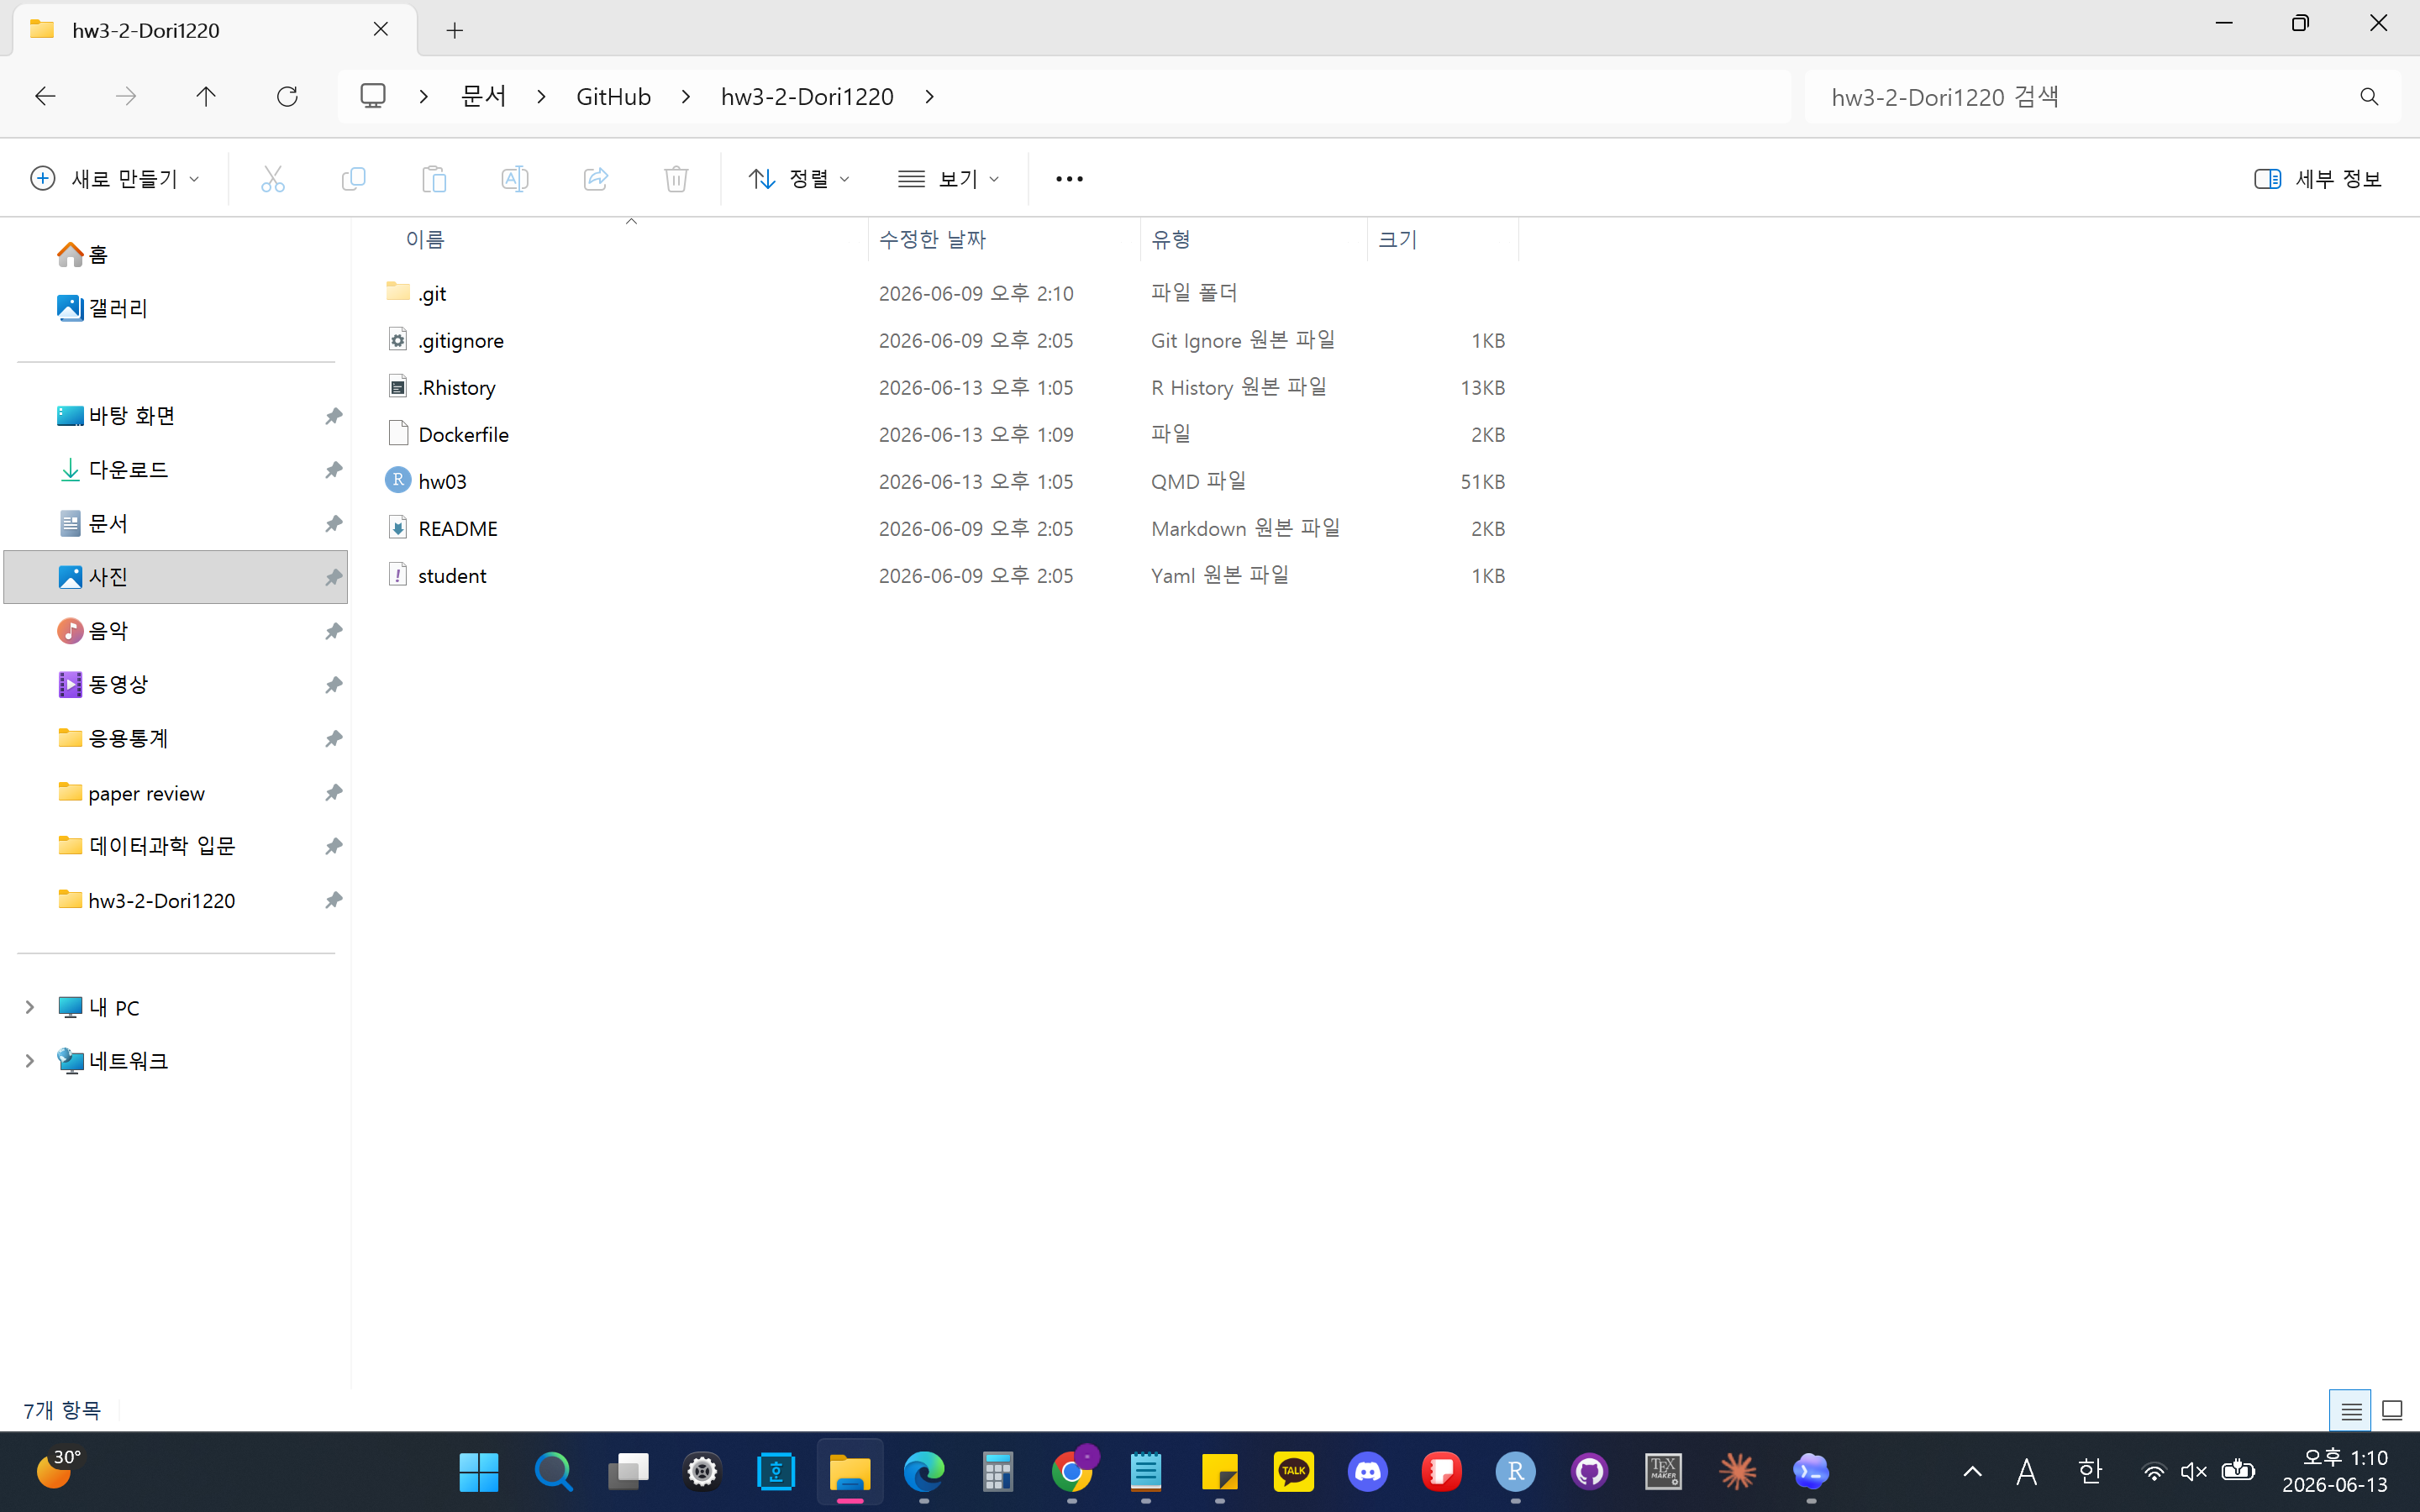
<figcaption aria-hidden="true">Docker 파일 생성</figcaption>
</figure>

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

In [ ]:
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest

### 답안

<figure>
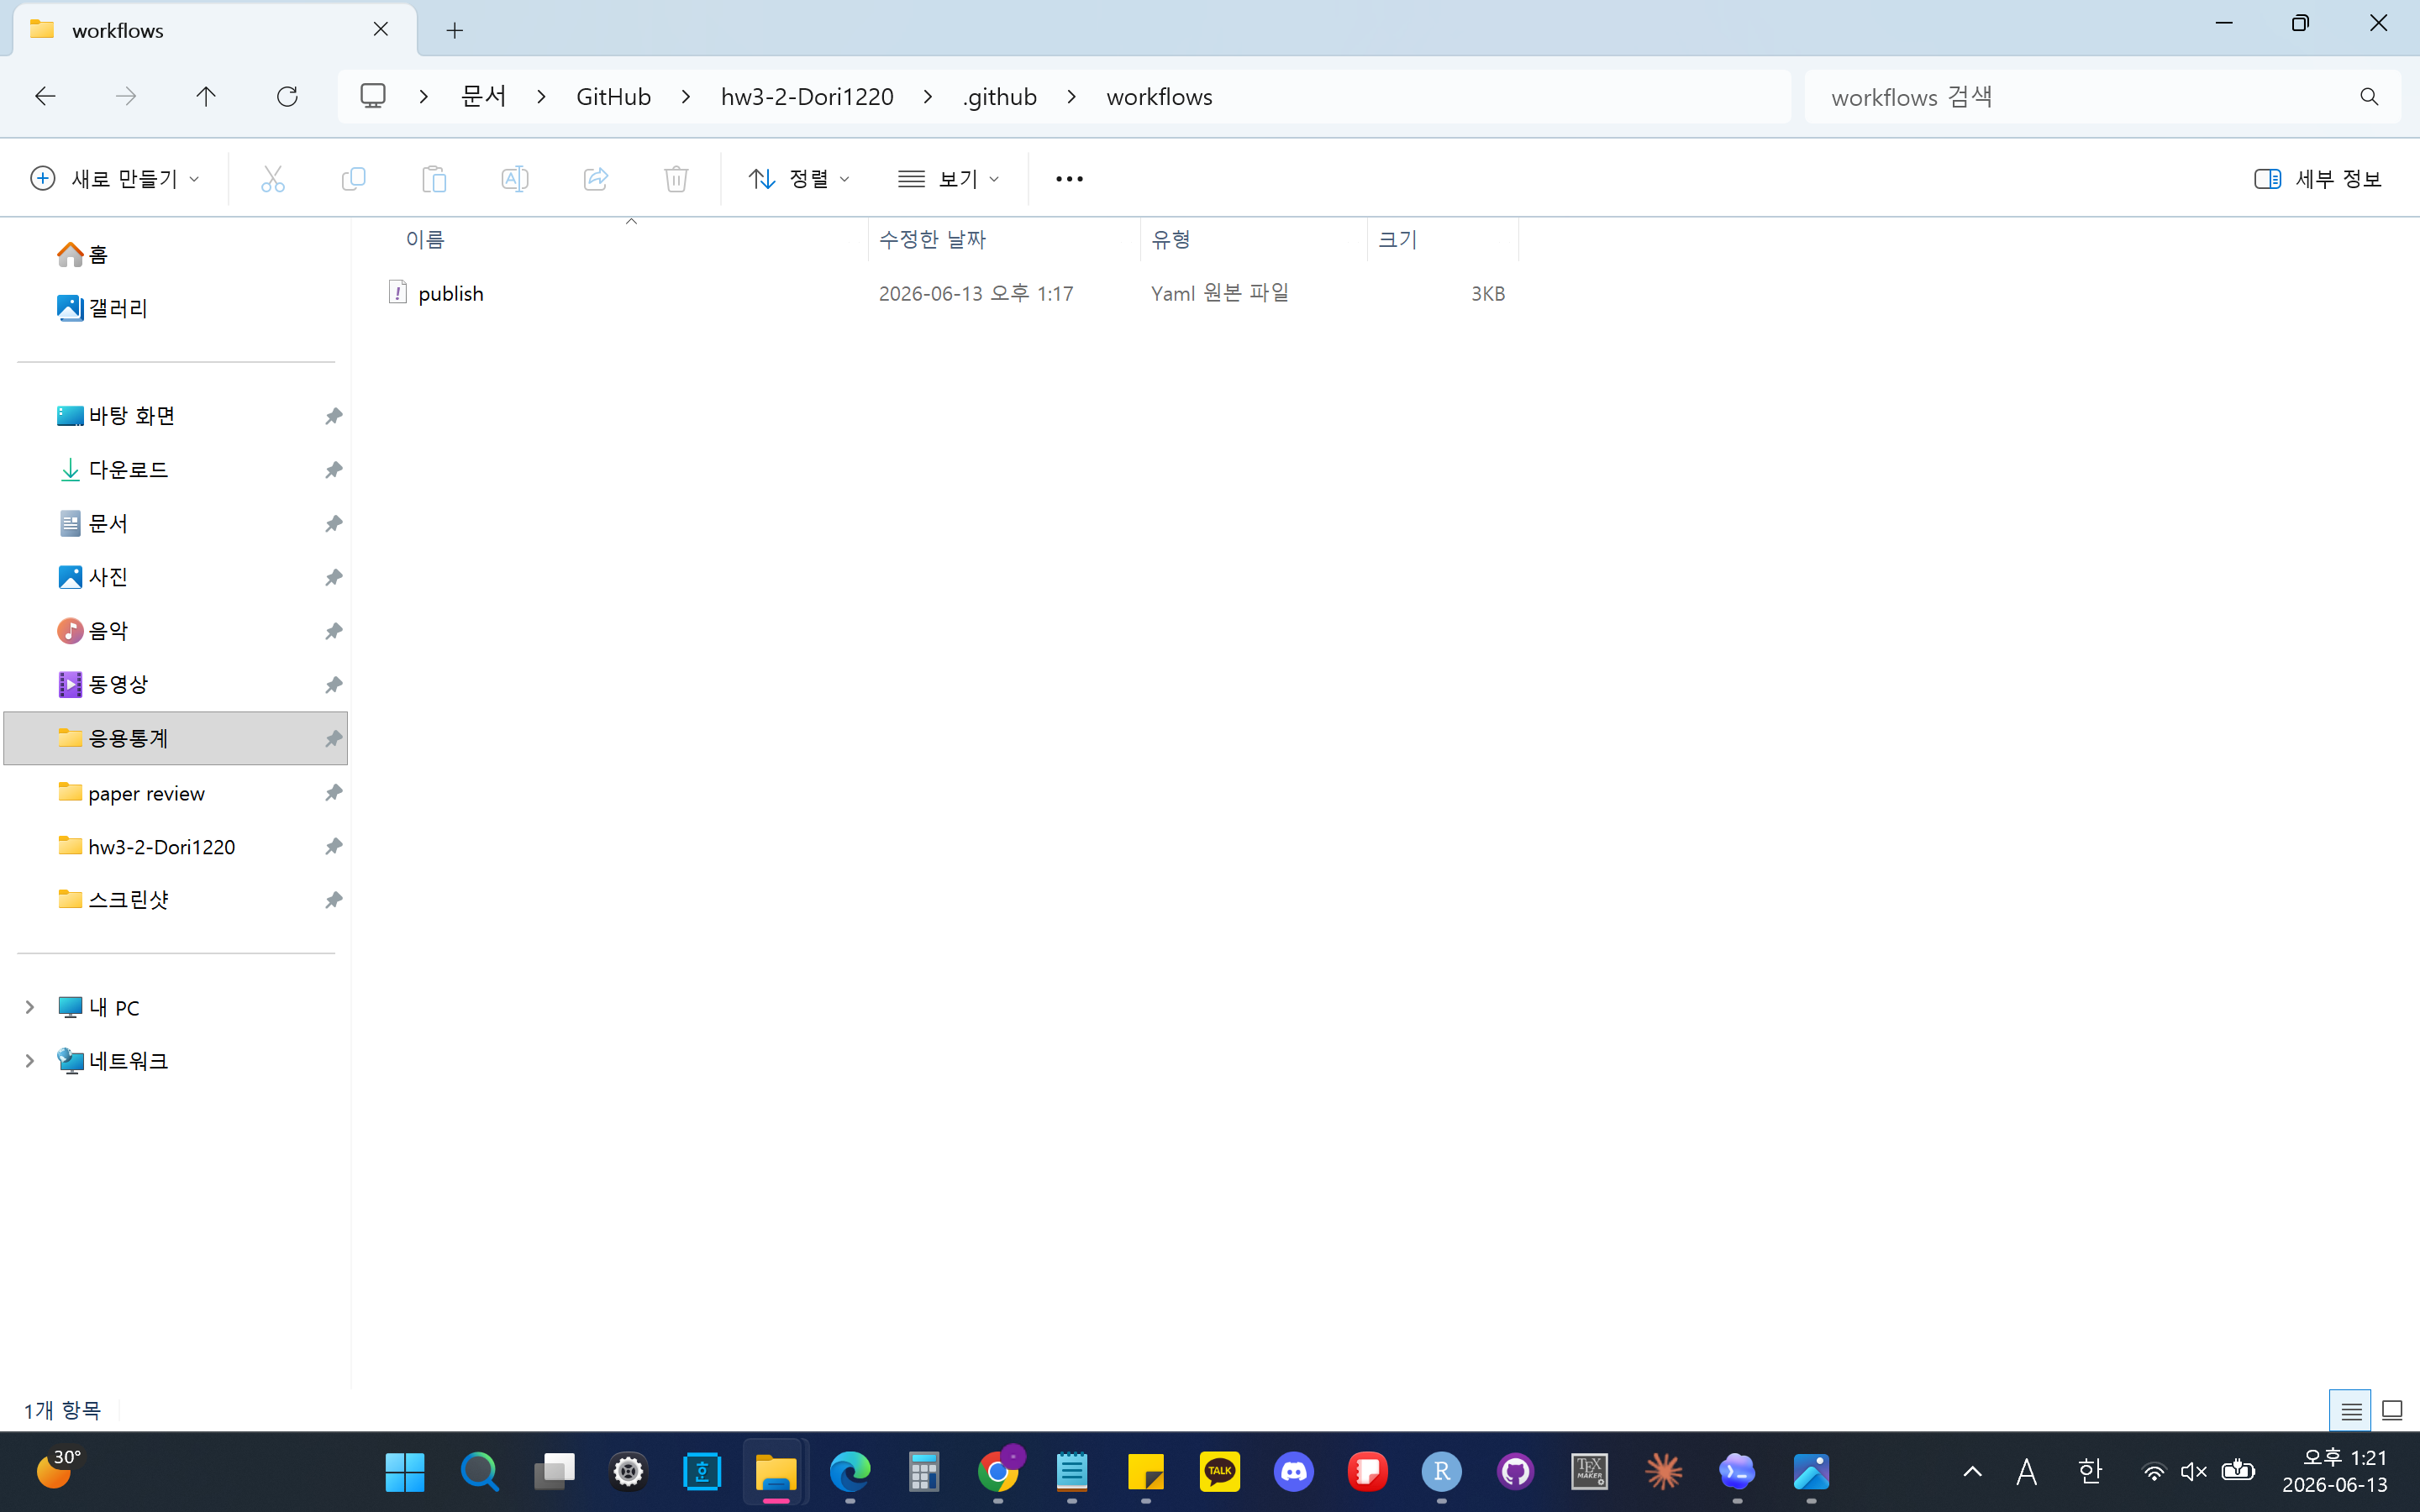
<figcaption aria-hidden="true">publish.yml 생성</figcaption>
</figure>

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

In [ ]:
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/gh/<유저명>/snu-stat/<repo명>/gh-pages?filepath=hw03.ipynb

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이며, `<repo명>`은 hw3-로
시작하는 제출자의 repository 이름이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안

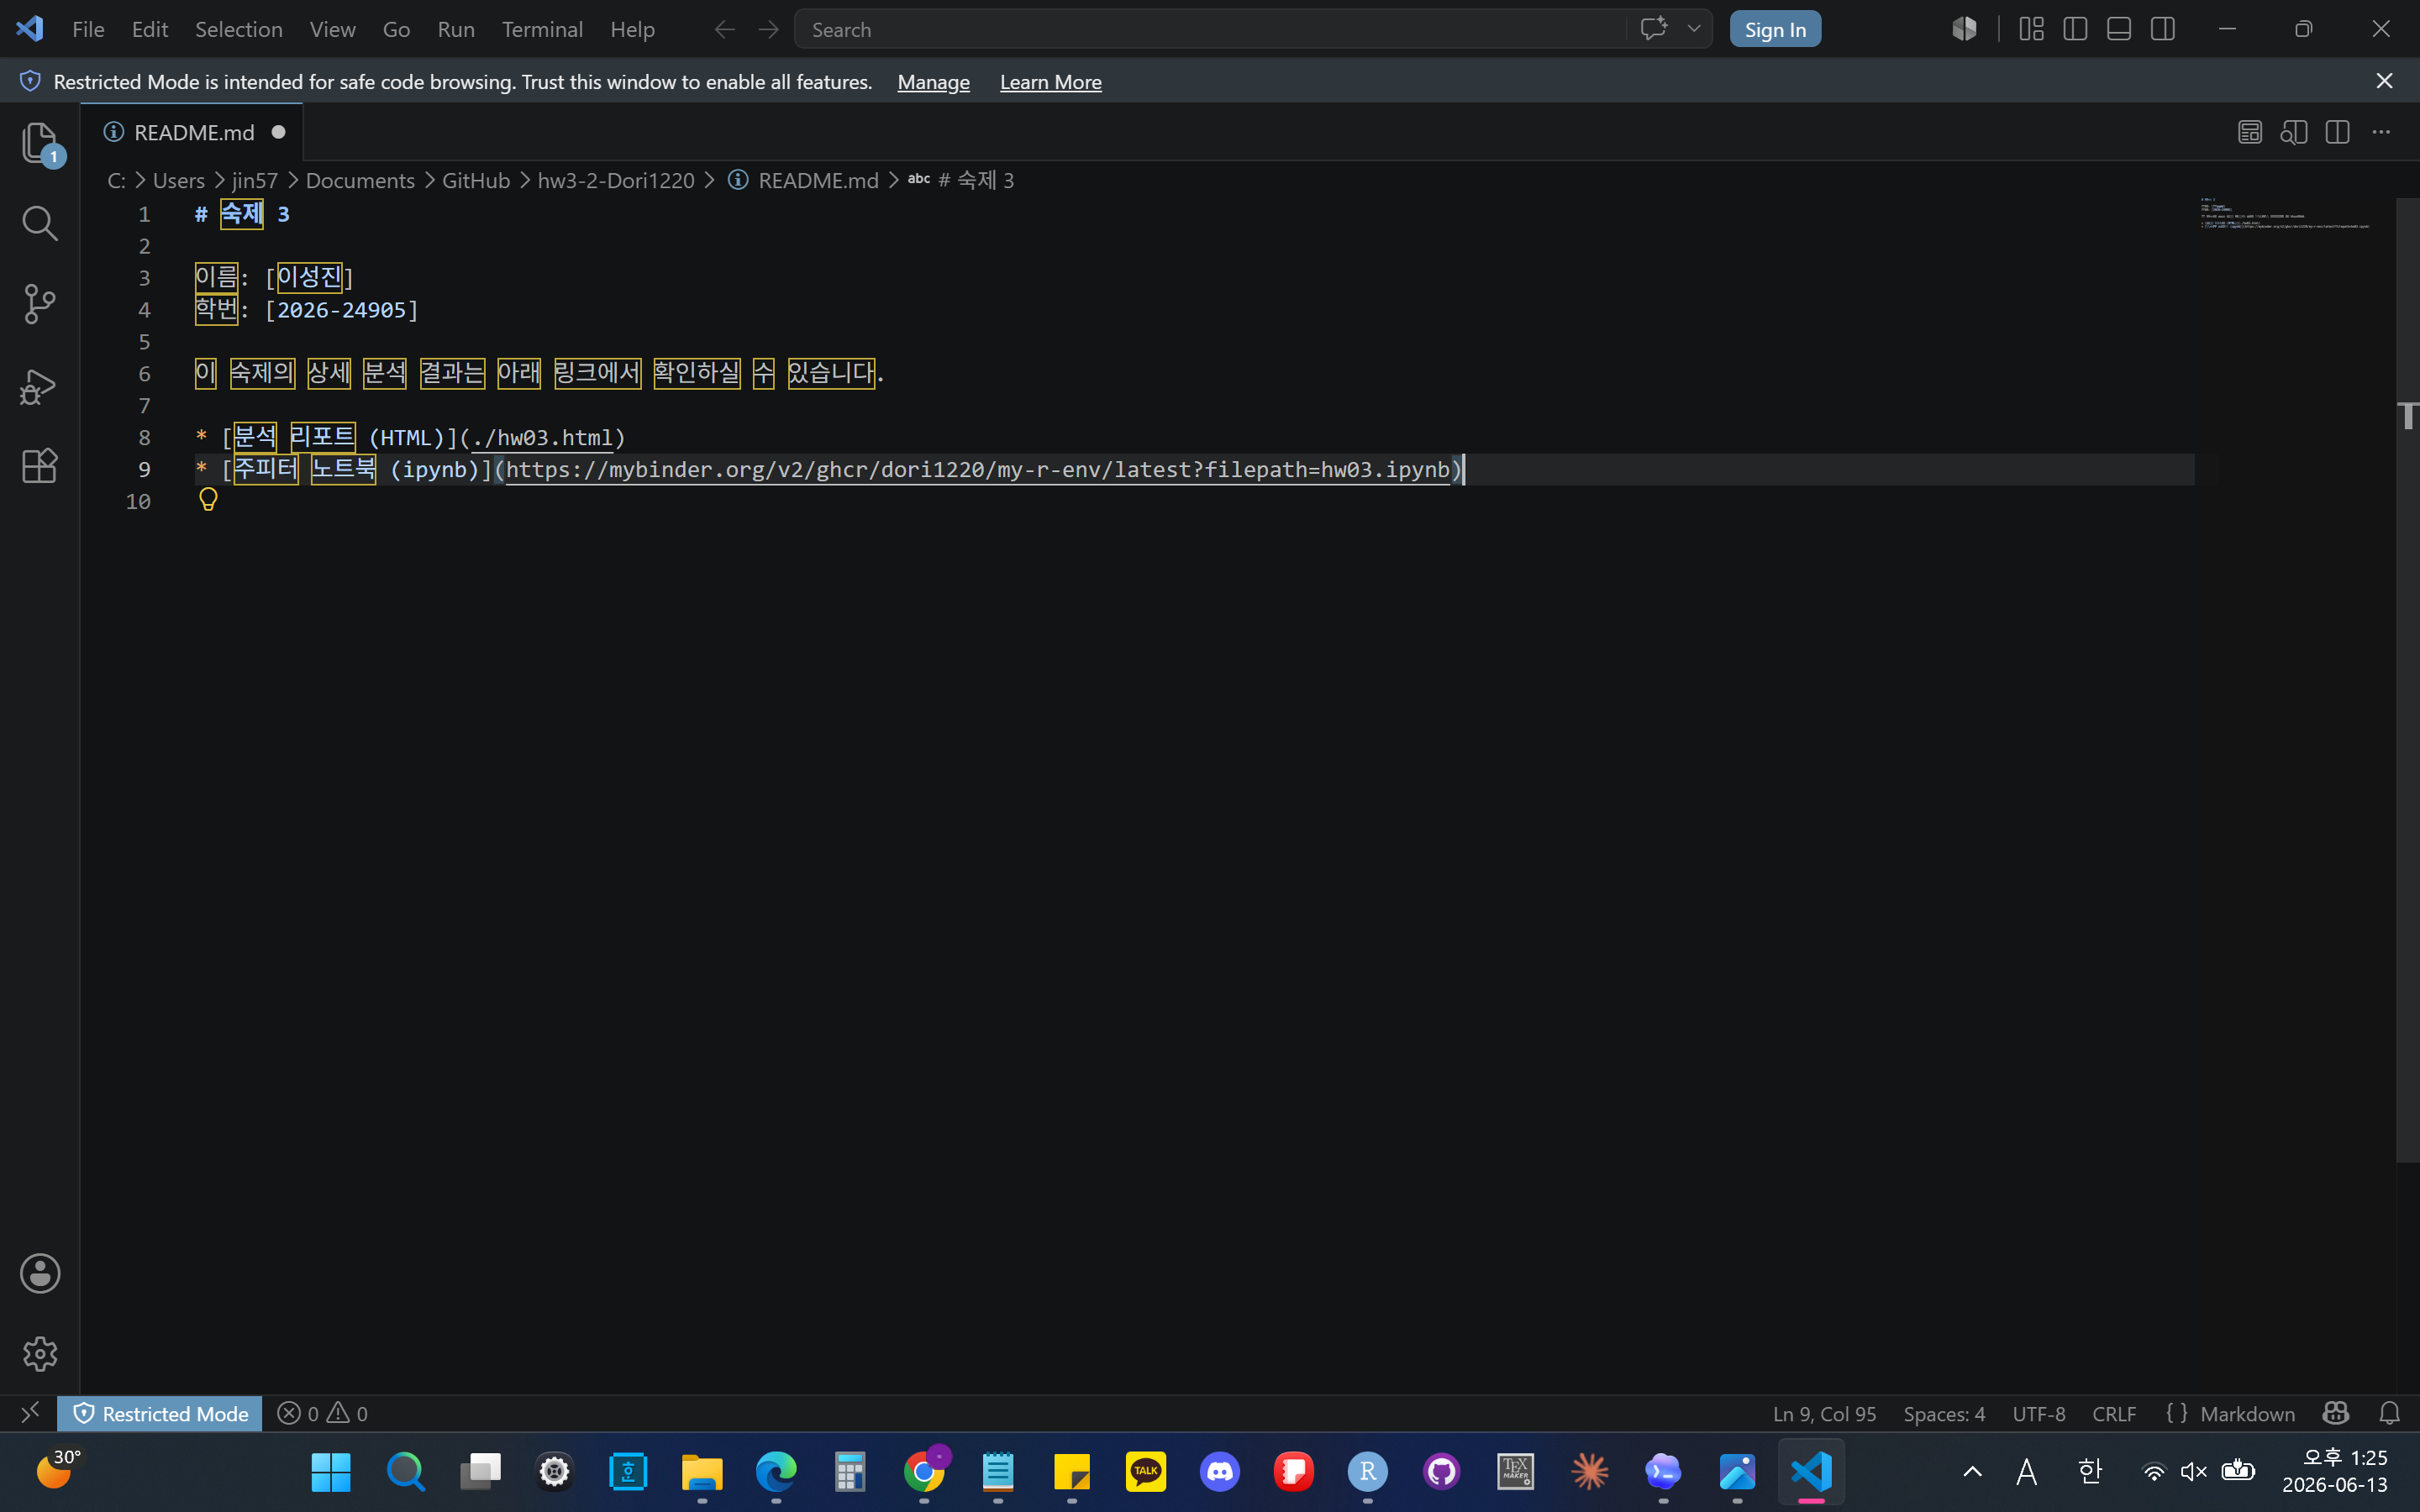 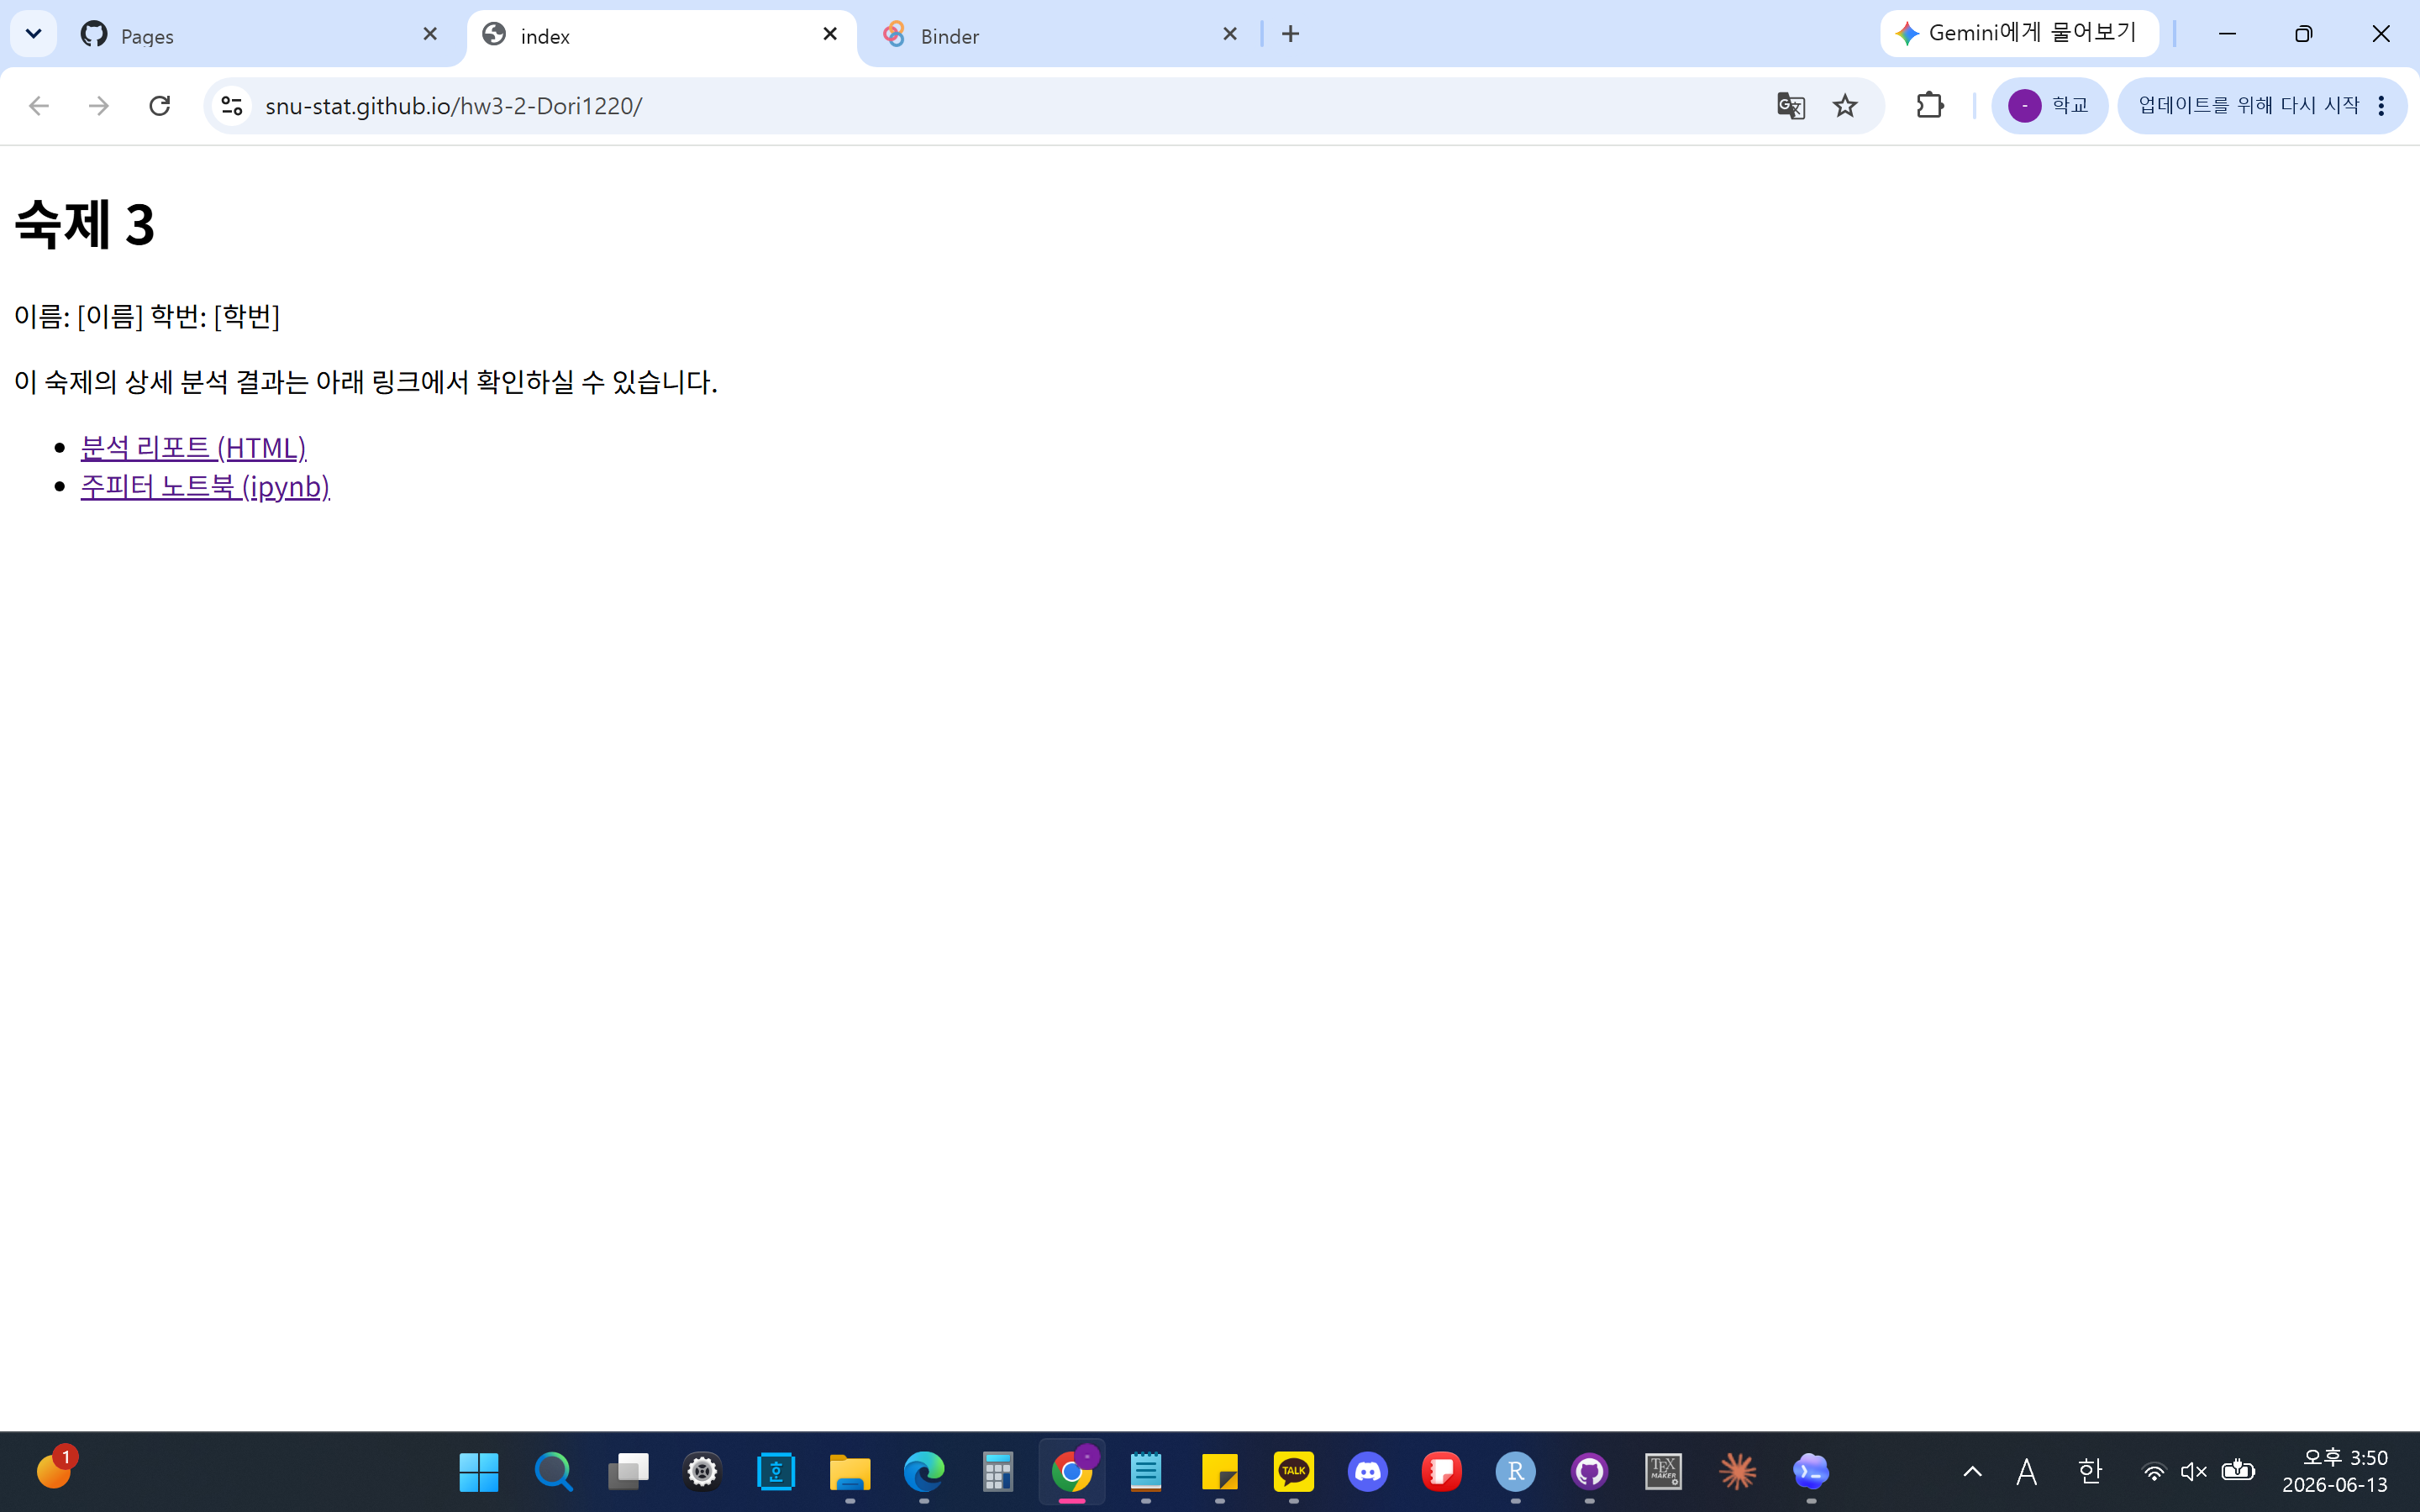